# Great Britain Electricity Demand
## Demand patterns, forecasting and variance analysis

**Tanishk Nanasaheb Shinde**  
**Data:** NESO historic demand, 2023–2025  
**Target:** National Demand (`ND`), measured in MW

I analyse how electricity demand changes through the day, week and year, then
compare a previous-week forecast with ridge regression and gradient boosting.
I use 2023 for training, 2024 for model selection and 2025 for the final test.
The analysis ends with one interval-level CSV for my Tableau dashboards.

To rerun the notebook, keep the three annual CSVs alongside it or in a `data/`
folder. Set `INPUT_DIR` if the files are elsewhere. `OUTPUT_DIR` controls where
the Tableau CSV is saved.


### Setup
I import the libraries, set a fixed random seed and use the same chart style
throughout. I also record the package versions so I can reproduce the results.


In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

INPUT_DIR = None
OUTPUT_DIR = Path.cwd()
SEED = 42
TZ = 'Europe/London'
SNAPSHOT_DATE = '2026-10-05'
TRAIN_END = pd.Timestamp('2023-12-30')
VALIDATION_END = pd.Timestamp('2024-12-30')
TEST_END = pd.Timestamp('2025-12-31')
np.random.seed(SEED)
pd.set_option('display.max_columns', 16)
pd.set_option('display.max_rows', 24)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 115, 'savefig.dpi': 140, 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
COLORS = {'Actual': '#142d4e', 'Seasonal naive': '#db8b22',
          'Ridge': '#7152a3', 'Gradient boosting': '#008f88'}

def show_table(frame, decimals=2):
    display(frame.round(decimals) if isinstance(frame, pd.DataFrame) else frame)

def show_chart(fig, title):
    fig.suptitle(title, fontsize=15, fontweight='bold', color='#142d4e')
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    display(fig)
    plt.close(fig)

versions = pd.DataFrame([
    {'Package': 'Python', 'Version': platform.python_version()},
    *[{'Package': module.__name__, 'Version': module.__version__}
      for module in (pd, np, matplotlib, sns, scipy, sklearn)],
])
show_table(versions)
print('Random seed:', SEED)


,Package,Version
0,Python,3.12.14
1,pandas,2.2.3
2,numpy,2.3.5
3,matplotlib,3.10.8
4,seaborn,0.13.2
5,scipy,1.17.0
6,sklearn,1.8.0


Random seed: 42


The version table records the environment used for this analysis. The input
and output folders are the only settings I need to change when running it elsewhere.


## 1. Load the annual demand files
I read the 2023, 2024 and 2025 CSVs, standardise their column names and parse
the different date formats. I keep the original filenames and file hashes
so each record can be traced back to its source.

`ND` is the metered generation requirement excluding station load,
pumped-storage pumping and interconnector exports. `TSD` includes those
additional requirements. The embedded wind and solar columns are estimates
for distribution-connected generation. I use them as descriptive context.


In [2]:
def locate_input_directory():
    directories = ([Path(INPUT_DIR)] if INPUT_DIR is not None else [
        Path.cwd(), Path.cwd() / 'data', Path.cwd() / 'upload',
        Path.cwd().parent / 'upload', Path.cwd().parent / 'data',
    ])
    for directory in directories:
        if all(list(directory.glob(f'demanddata_{year}*.csv'))
               for year in (2023, 2024, 2025)):
            return directory
    raise FileNotFoundError('Place the 2023, 2024 and 2025 demand CSVs together, '
                            'or set INPUT_DIR to their folder.')

data_dir = locate_input_directory()
frames, manifest_rows = [], []
for year in (2023, 2024, 2025):
    matches = sorted(data_dir.glob(f'demanddata_{year}*.csv'))
    if len(matches) != 1:
        raise ValueError(f'Expected one input for {year}; found {len(matches)}. '
                         'Choose one source version and remove extra copies from INPUT_DIR.')
    path = matches[0]
    frame = pd.read_csv(path)
    frame.columns = frame.columns.str.strip().str.upper()
    if not {'SETTLEMENT_DATE', 'SETTLEMENT_PERIOD', 'ND'}.issubset(frame.columns):
        raise ValueError(f'Missing required columns in {path.name}')
    frame['SettlementDate'] = pd.to_datetime(frame['SETTLEMENT_DATE'],
                                             format='mixed', errors='coerce').dt.normalize()
    if frame['SettlementDate'].isna().any():
        raise ValueError(f'Unparseable settlement dates in {path.name}')
    if set(frame['SettlementDate'].dt.year) != {year}:
        raise ValueError(f'Unexpected year in {path.name}')
    frame['SourceFile'] = path.name
    frame['SourceSHA256'] = hashlib.sha256(path.read_bytes()).hexdigest()
    frame['SourceSnapshotDate'] = SNAPSHOT_DATE
    manifest_rows.append({
        'Year': year, 'File': path.name, 'Rows': len(frame),
        'Source columns': len(pd.read_csv(path, nrows=0).columns),
        'First date': frame['SettlementDate'].min().date(),
        'Last date': frame['SettlementDate'].max().date(),
        'SHA256': frame['SourceSHA256'].iloc[0],
    })
    frames.append(frame)

raw = pd.concat(frames, ignore_index=True)
source_numeric_cols = [column for column in raw.columns
                       if column not in {'SETTLEMENT_DATE', 'SettlementDate',
                                         'SourceFile', 'SourceSHA256', 'SourceSnapshotDate'}]
numeric_parse_failures = {}
for column in source_numeric_cols:
    original = raw[column]
    numeric = pd.to_numeric(original, errors='coerce')
    failures = original.notna() & numeric.isna()
    numeric_parse_failures[column] = int(failures.sum())
    raw[column] = numeric
if any(numeric_parse_failures.values()):
    raise ValueError(f'Non-numeric source fields: {numeric_parse_failures}')
sp = raw['SETTLEMENT_PERIOD']
if sp.isna().any() or (sp % 1 != 0).any():
    raise ValueError('Settlement periods must be non-missing integers.')
raw['SETTLEMENT_PERIOD'] = sp.astype(int)
manifest = pd.DataFrame(manifest_rows)
show_table(manifest)
print(f'Combined source: {len(raw):,} rows, {raw.SettlementDate.nunique():,} dates.')
show_table(raw[['SETTLEMENT_DATE', 'SETTLEMENT_PERIOD', 'ND', 'TSD',
                'EMBEDDED_WIND_GENERATION', 'EMBEDDED_SOLAR_GENERATION']].head(8))


,Year,File,Rows,Source columns,First date,Last date,SHA256
0,2023,demanddata_2023(1).csv,17520,22,2023-01-01,2023-12-31,cb6f7b91dd6a5defbdd918e3db440b8e6cec5855ef18a8...
1,2024,demanddata_2024(1).csv,17568,22,2024-01-01,2024-12-31,fa7895b6e9ab5eb1b450949d969cb18ffeb6005359fc71...
2,2025,demanddata_2025(2).csv,17520,22,2025-01-01,2025-12-31,8b8be946bbb084bc28fbf95a71fad0fceb5543b98e0275...


Combined source: 52,608 rows, 1,096 dates.


,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,EMBEDDED_WIND_GENERATION,EMBEDDED_SOLAR_GENERATION
0,01-Jan-23,1,21043,24680,2815,0
1,01-Jan-23,2,21756,25289,2793,0
2,01-Jan-23,3,21348,25269,2773,0
3,01-Jan-23,4,20586,24574,2753,0
4,01-Jan-23,5,19781,24135,2712,0
5,01-Jan-23,6,19077,23505,2671,0
6,01-Jan-23,7,18511,22969,2615,0
7,01-Jan-23,8,17803,22278,2558,0


The three files contain 52,608 half-hourly records covering 1 January 2023
to 31 December 2025. The combined dataset includes 2024's leap day.


## 2. Check dates, duplicates and coverage
I use settlement date and settlement period as the source key. Conflicting
duplicate keys stop the analysis; exact repeated rows are counted before removal.

I build the expected intervals from one local midnight to the next in
`Europe/London`, then convert them to UTC. This handles the 46-period spring
day and 50-period autumn day without forcing every date to have 48 records.


In [3]:
key_cols = ['SettlementDate', 'SETTLEMENT_PERIOD']
source_values = [c for c in source_numeric_cols if c != 'SETTLEMENT_PERIOD']
duplicate_keys = raw.duplicated(key_cols, keep=False)
conflicting_keys = (raw.loc[duplicate_keys].groupby(key_cols)[source_values]
                    .nunique(dropna=False).gt(1).any(axis=1))
if conflicting_keys.any():
    raise ValueError('Conflicting duplicate settlement keys require source review.')
removed_mask = raw.duplicated(key_cols, keep='first')
duplicates_by_day = raw.loc[removed_mask].groupby('SettlementDate').size()
clean = raw.loc[~removed_mask].copy()
observed_by_day = clean.groupby('SettlementDate').size()

grid_parts = []
for date in pd.date_range('2023-01-01', '2025-12-31', freq='D'):
    start = date.tz_localize(TZ).tz_convert('UTC')
    end = (date + pd.Timedelta(days=1)).tz_localize(TZ).tz_convert('UTC')
    times = pd.date_range(start, end, freq='30min', inclusive='left')
    grid_parts.append(pd.DataFrame({
        'SettlementDate': date, 'SETTLEMENT_PERIOD': np.arange(1, len(times) + 1),
        'UTCStart': times, 'ExpectedPeriodsDay': len(times),
    }))
grid = pd.concat(grid_parts, ignore_index=True)
bad_keys = clean.merge(grid[key_cols], how='left', on=key_cols, indicator=True)
if bad_keys['_merge'].eq('left_only').any():
    raise ValueError('A source settlement period is outside the expected local day.')
df = grid.merge(clean, on=key_cols, how='left', validate='one_to_one', indicator=True)
df['SourceRecordPresent'] = df.pop('_merge').eq('both').astype(int)
df = df.sort_values('UTCStart').reset_index(drop=True)
local = df['UTCStart'].dt.tz_convert(TZ)
df['LocalStart'] = local
df['ClockSlot'] = local.dt.hour * 2 + local.dt.minute // 30
df['ClockTime'] = local.dt.strftime('%H:%M')
df['LocalTimeOccurrence'] = df.groupby(['SettlementDate', 'ClockSlot']).cumcount() + 1
df['UTCOffsetMinutes'] = local.map(lambda value: int(value.utcoffset().total_seconds() / 60))
df['IsBST'] = df['UTCOffsetMinutes'].eq(60).astype(int)
df['IntervalHours'] = 0.5
df['IntervalID'] = df['UTCStart'].dt.strftime('%Y-%m-%dT%H:%M:%SZ')
df['ObservedPeriodsDay'] = df['SettlementDate'].map(observed_by_day).fillna(0).astype(int)
df['MissingPeriodsDay'] = df['ExpectedPeriodsDay'] - df['ObservedPeriodsDay']
df['DuplicateRowsRemovedDay'] = df['SettlementDate'].map(duplicates_by_day).fillna(0).astype(int)
df['DayAuditAnchor'] = df['SETTLEMENT_PERIOD'].eq(1).astype(int)
df['MissingPeriodFlag'] = 1 - df['SourceRecordPresent']
df['SourceMissingFieldsCount'] = df[source_values].isna().sum(axis=1)
df['MissingActualFlag'] = df['ND'].isna().astype(int)
df['InvalidDemandFlag'] = (df['ND'].notna() & df['ND'].le(0)).astype(int)
df['ActualDemandMW'] = df['ND'].where(df['InvalidDemandFlag'].eq(0))
df['DemandEnergyMWh'] = df['ActualDemandMW'] * df['IntervalHours']
df['ClockChangeDay'] = np.select(
    [df.ExpectedPeriodsDay.eq(46), df.ExpectedPeriodsDay.eq(50)],
    ['Spring: 46 periods', 'Autumn: 50 periods'], default='Normal: 48 periods')

coverage_rows = []
for year, part in df.groupby(df.SettlementDate.dt.year):
    coverage_rows.append({
        'Year': year, 'Expected intervals': len(part),
        'Observed intervals': int(part.SourceRecordPresent.sum()),
        'Coverage (%)': 100 * part.SourceRecordPresent.mean(),
        'Missing ND': int(part.MissingActualFlag.sum()),
        'Invalid ND': int(part.InvalidDemandFlag.sum()),
        'Duplicate rows removed': int(part.loc[part.DayAuditAnchor.eq(1), 'DuplicateRowsRemovedDay'].sum()),
        'Missing numeric source fields': int(part.SourceMissingFieldsCount.sum()),
    })
coverage = pd.DataFrame(coverage_rows)
show_table(coverage)
clock_days = (df.loc[df.ExpectedPeriodsDay.ne(48)]
              .groupby('SettlementDate').agg(
                  Expected=('ExpectedPeriodsDay', 'first'),
                  Observed=('SourceRecordPresent', 'sum'),
                  FirstUTC=('UTCStart', 'min'), LastUTC=('UTCStart', 'max')))
show_table(clock_days)
show_table(df.loc[df.SettlementDate.eq(pd.Timestamp('2025-10-26')),
                  ['SETTLEMENT_PERIOD', 'UTCStart', 'LocalStart', 'ClockTime',
                   'LocalTimeOccurrence']].head(8))
assert df.IntervalID.is_unique
assert df.UTCStart.diff().dropna().eq(pd.Timedelta(minutes=30)).all()
assert (df.ExpectedPeriodsDay.isin([46, 48, 50])).all()
print('Coverage and UTC continuity checks passed. No source actuals were imputed.')


,Year,Expected intervals,Observed intervals,Coverage (%),Missing ND,Invalid ND,Duplicate rows removed,Missing numeric source fields
0,2023,17520,17520,100.000,0,0,0,0
1,2024,17568,17568,100.000,0,0,0,0
2,2025,17520,17520,100.000,0,0,0,0


,Expected,Observed,FirstUTC,LastUTC
SettlementDate,,,,
2023-03-26,46,46,2023-03-26 00:00:00+00:00,2023-03-26 22:30:00+00:00
2023-10-29,50,50,2023-10-28 23:00:00+00:00,2023-10-29 23:30:00+00:00
2024-03-31,46,46,2024-03-31 00:00:00+00:00,2024-03-31 22:30:00+00:00
2024-10-27,50,50,2024-10-26 23:00:00+00:00,2024-10-27 23:30:00+00:00
2025-03-30,46,46,2025-03-30 00:00:00+00:00,2025-03-30 22:30:00+00:00
2025-10-26,50,50,2025-10-25 23:00:00+00:00,2025-10-26 23:30:00+00:00


,SETTLEMENT_PERIOD,UTCStart,LocalStart,ClockTime,LocalTimeOccurrence
49390,1,2025-10-25 23:00:00+00:00,2025-10-26 00:00:00+01:00,00:00,1
49391,2,2025-10-25 23:30:00+00:00,2025-10-26 00:30:00+01:00,00:30,1
49392,3,2025-10-26 00:00:00+00:00,2025-10-26 01:00:00+01:00,01:00,1
49393,4,2025-10-26 00:30:00+00:00,2025-10-26 01:30:00+01:00,01:30,1
49394,5,2025-10-26 01:00:00+00:00,2025-10-26 01:00:00+00:00,01:00,2
49395,6,2025-10-26 01:30:00+00:00,2025-10-26 01:30:00+00:00,01:30,2
49396,7,2025-10-26 02:00:00+00:00,2025-10-26 02:00:00+00:00,02:00,1
49397,8,2025-10-26 02:30:00+00:00,2025-10-26 02:30:00+00:00,02:30,1


Coverage and UTC continuity checks passed. No source actuals were imputed.


All expected intervals are present, with no duplicate keys or missing demand
values. The six clock-change dates have the correct period counts. UTC also
distinguishes the repeated 01:00 and 01:30 intervals in autumn.


I check missing values separately from zeros and plot coverage by year.
Zero solar generation at night is valid, so I keep those values.


,Missing cells,Zero cells
ND,0,0
TSD,0,0
ENGLAND_WALES_DEMAND,0,0
EMBEDDED_WIND_GENERATION,0,0
EMBEDDED_WIND_CAPACITY,0,0
EMBEDDED_SOLAR_GENERATION,0,25846
EMBEDDED_SOLAR_CAPACITY,0,0
NON_BM_STOR,0,52606
PUMP_STORAGE_PUMPING,0,426
SCOTTISH_TRANSFER,0,1349


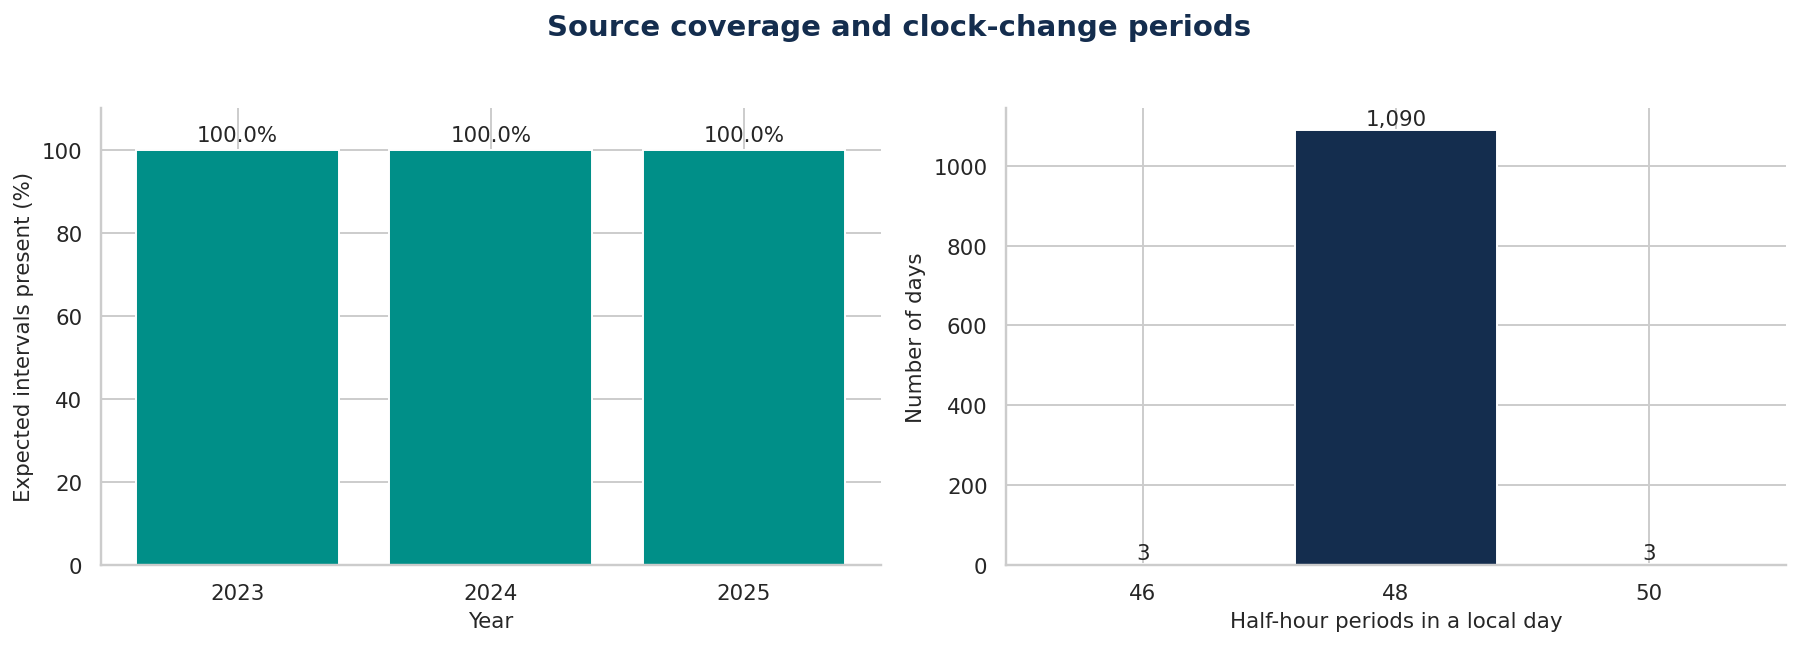

In [4]:
source_missing = raw[source_values].isna().sum().rename('Missing cells').to_frame()
zero_counts = raw[source_values].eq(0).sum().rename('Zero cells')
source_missing['Zero cells'] = zero_counts
show_table(source_missing)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
axes[0].bar(coverage['Year'].astype(str), coverage['Coverage (%)'], color='#008f88')
axes[0].set(ylim=(0, 110), ylabel='Expected intervals present (%)', xlabel='Year')
for i, value in enumerate(coverage['Coverage (%)']):
    axes[0].text(i, value + 2, f'{value:.1f}%', ha='center')
daily_period_counts = df.groupby('SettlementDate').ExpectedPeriodsDay.first().value_counts().sort_index()
axes[1].bar(daily_period_counts.index.astype(str), daily_period_counts.values, color='#142d4e')
axes[1].set(xlabel='Half-hour periods in a local day', ylabel='Number of days')
for i, value in enumerate(daily_period_counts.values):
    axes[1].text(i, value + 12, f'{value:,}', ha='center')
show_chart(fig, 'Source coverage and clock-change periods')


Coverage is 100% in each year. There are 1,090 normal days, three 23-hour days
and three 25-hour days. No missing source values need to be filled.


## 3. Explore demand patterns
I add weekday, weekend, month, season and local-time fields. The holiday
indicator uses England and Wales bank holidays, including the 2023 coronation.
It approximates GB working patterns and excludes additional Scottish holidays.

I convert interval power to energy using `ND × 0.5`, since each settlement
period lasts half an hour. These energy totals use the ND definition.


In [5]:
holiday_dates = {
    '2023-01-02': "New Year's Day (substitute)", '2023-04-07': 'Good Friday',
    '2023-04-10': 'Easter Monday', '2023-05-01': 'Early May',
    '2023-05-08': 'Coronation', '2023-05-29': 'Spring bank holiday',
    '2023-08-28': 'Summer bank holiday', '2023-12-25': 'Christmas Day',
    '2023-12-26': 'Boxing Day',
    '2024-01-01': "New Year's Day", '2024-03-29': 'Good Friday',
    '2024-04-01': 'Easter Monday', '2024-05-06': 'Early May',
    '2024-05-27': 'Spring bank holiday', '2024-08-26': 'Summer bank holiday',
    '2024-12-25': 'Christmas Day', '2024-12-26': 'Boxing Day',
    '2025-01-01': "New Year's Day", '2025-04-18': 'Good Friday',
    '2025-04-21': 'Easter Monday', '2025-05-05': 'Early May',
    '2025-05-26': 'Spring bank holiday', '2025-08-25': 'Summer bank holiday',
    '2025-12-25': 'Christmas Day', '2025-12-26': 'Boxing Day',
}
df['Year'] = df.SettlementDate.dt.year
df['MonthNumber'] = df.SettlementDate.dt.month
df['MonthName'] = df.SettlementDate.dt.strftime('%b')
df['YearMonth'] = df.SettlementDate.dt.strftime('%Y-%m')
df['DayOfWeekNumber'] = df.SettlementDate.dt.dayofweek
df['DayOfWeekName'] = df.SettlementDate.dt.day_name()
df['IsWeekend'] = df.DayOfWeekNumber.ge(5).astype(int)
df['DayType'] = np.where(df.IsWeekend.eq(1), 'Weekend', 'Weekday')
df['IsBankHolidayEW'] = df.SettlementDate.dt.strftime('%Y-%m-%d').isin(holiday_dates).astype(int)
df['BankHolidayName'] = df.SettlementDate.dt.strftime('%Y-%m-%d').map(holiday_dates).fillna('None')
df['IsChristmasPeriod'] = (df.MonthNumber.eq(12) & df.SettlementDate.dt.day.ge(24)).astype(int)
df['Season'] = df.MonthNumber.map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                  3: 'Spring', 4: 'Spring', 5: 'Spring',
                                  6: 'Summer', 7: 'Summer', 8: 'Summer',
                                  9: 'Autumn', 10: 'Autumn', 11: 'Autumn'})
df['HourOfDay'] = df.ClockSlot / 2
df['WeekStart'] = df.SettlementDate - pd.to_timedelta(df.DayOfWeekNumber, unit='D')

annual = df.groupby('Year').agg(
    Intervals=('IntervalID', 'size'), MeanDemandMW=('ActualDemandMW', 'mean'),
    MinimumDemandMW=('ActualDemandMW', 'min'), PeakDemandMW=('ActualDemandMW', 'max'),
    DemandEnergyMWh=('DemandEnergyMWh', lambda series: series.sum(min_count=1)),
)
annual['DemandEnergyTWh'] = annual.DemandEnergyMWh / 1_000_000
annual['MeanDemandChangePct'] = annual.MeanDemandMW.pct_change() * 100
show_table(annual)
show_table(df[['ActualDemandMW', 'TSD', 'EMBEDDED_WIND_GENERATION',
               'EMBEDDED_SOLAR_GENERATION']].describe(percentiles=[.01, .25, .5, .75, .99]).T)
daily = df.groupby('SettlementDate').agg(
    MeanDemandMW=('ActualDemandMW', 'mean'), PeakDemandMW=('ActualDemandMW', 'max'),
    MinimumDemandMW=('ActualDemandMW', 'min'),
    DemandEnergyMWh=('DemandEnergyMWh', lambda series: series.sum(min_count=1)),
)
print(f'Overall mean ND: {df.ActualDemandMW.mean():,.0f} MW.')
print(f'Highest observed ND: {df.ActualDemandMW.max():,.0f} MW at '
      f'{df.loc[df.ActualDemandMW.idxmax(), "LocalStart"]}.')


,Intervals,MeanDemandMW,MinimumDemandMW,PeakDemandMW,DemandEnergyMWh,DemandEnergyTWh,MeanDemandChangePct
Year,,,,,,,
2023,17520,"26,051.750",13601,44109,"228,213,288.000",228.210,NaN
2024,17568,"26,286.760",15071,45202,"230,902,926.000",230.900,0.900
2025,17520,"26,158.070",12803,45924,"229,144,716.000",229.140,-0.490


,count,mean,std,min,1%,25%,50%,75%,99%,max
ActualDemandMW,"52,608.000","26,165.640","6,044.580","12,803.000","16,277.140","21,464.750","25,191.000","30,006.250","41,206.000","45,924.000"
TSD,"52,608.000","28,235.460","5,863.950","15,297.000","18,667.000","23,776.000","27,118.000","31,806.000","43,361.000","47,760.000"
EMBEDDED_WIND_GENERATION,"52,608.000","1,886.900","1,214.520",125.000,313.000,922.000,"1,563.000","2,602.000","5,356.930","5,962.000"
EMBEDDED_SOLAR_GENERATION,"52,608.000","1,750.920","2,750.570",0.000,0.000,0.000,5.000,"2,796.000","10,752.790","14,046.000"


Overall mean ND: 26,166 MW.
Highest observed ND: 45,924 MW at 2025-01-09 17:00:00+00:00.


Annual mean demand stays close to 26,000 MW across the three years. The
summary table also separates mean demand, peak demand and interval energy.


I plot daily mean demand with a trailing 28-day average to separate the
broader seasonal pattern from day-to-day changes. The second chart shows
the range between each day's minimum and maximum demand.


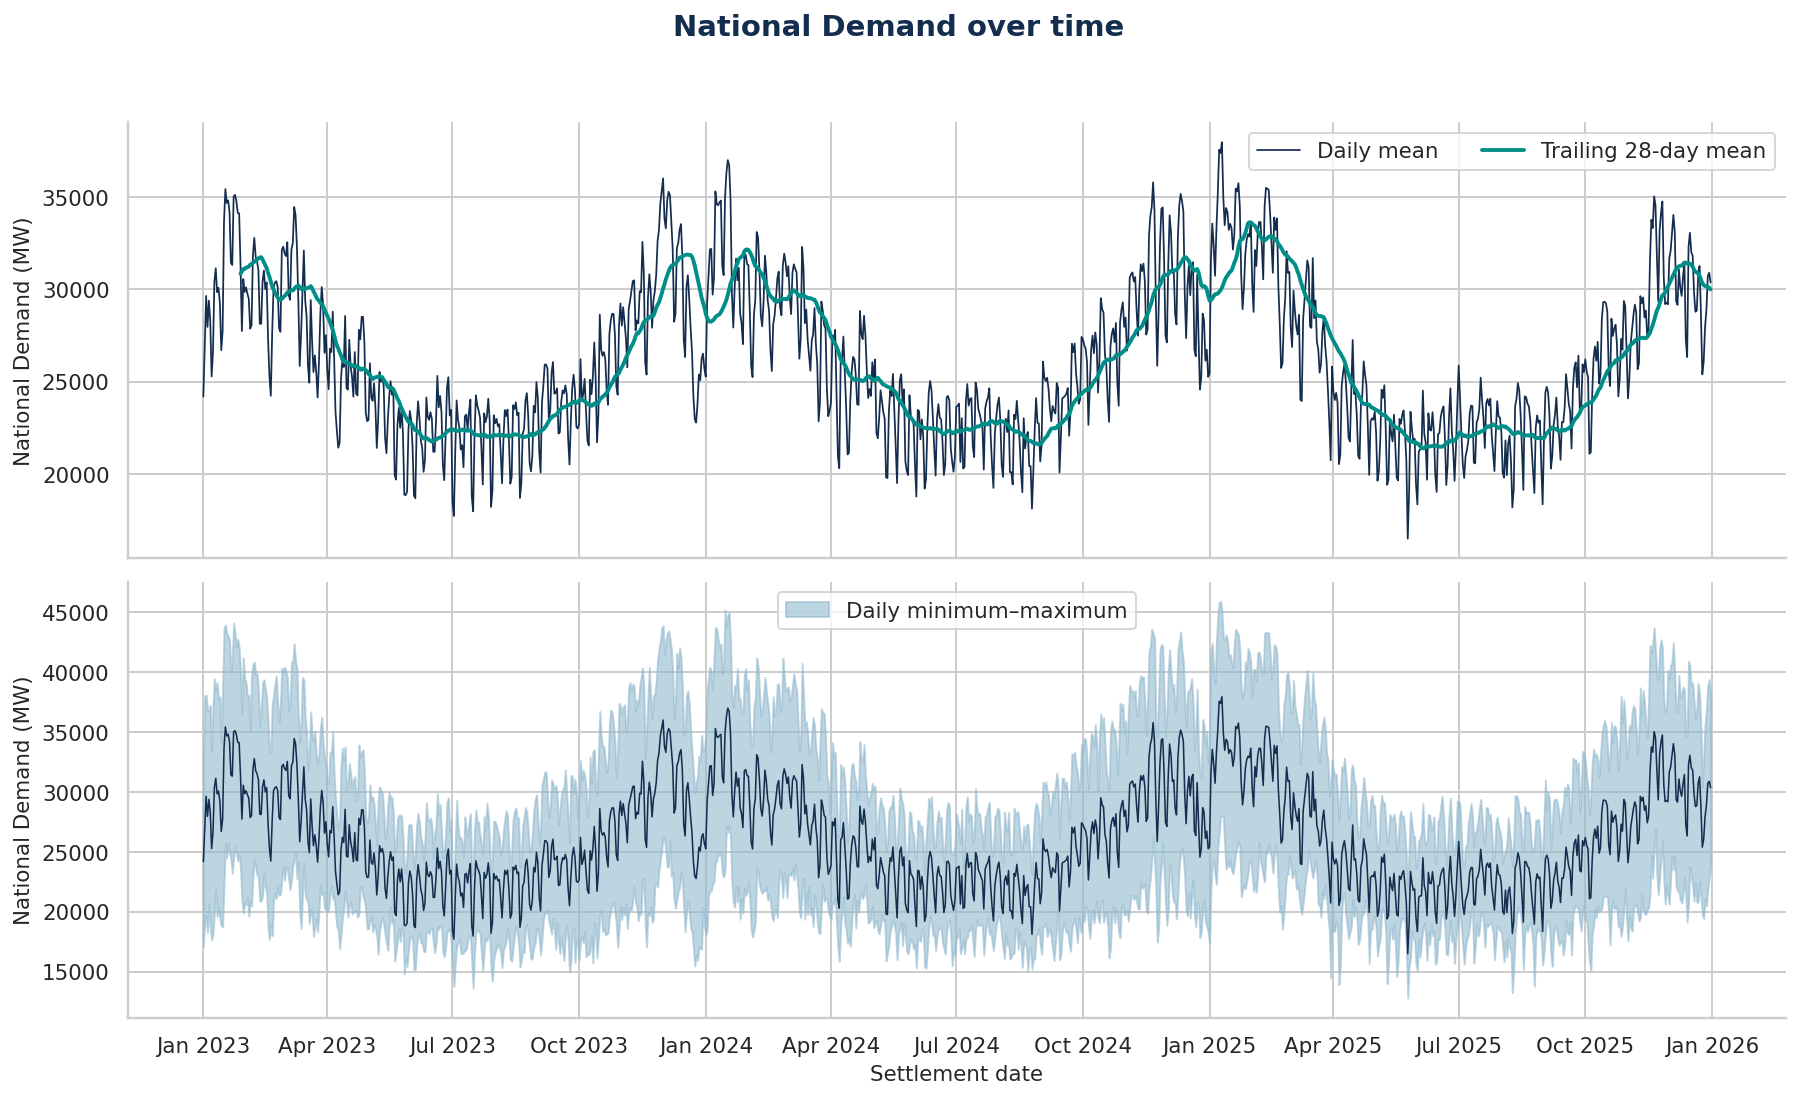

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(daily.index, daily.MeanDemandMW, color=COLORS['Actual'], lw=.9, label='Daily mean')
axes[0].plot(daily.index, daily.MeanDemandMW.rolling(28, min_periods=28).mean(),
             color=COLORS['Gradient boosting'], lw=2, label='Trailing 28-day mean')
axes[0].set(ylabel='National Demand (MW)')
axes[0].legend(ncol=2)
axes[1].fill_between(daily.index, daily.MinimumDemandMW, daily.PeakDemandMW,
                     color='#92b9ce', alpha=.6, label='Daily minimum–maximum')
axes[1].plot(daily.index, daily.MeanDemandMW, color=COLORS['Actual'], lw=.8)
axes[1].set(ylabel='National Demand (MW)', xlabel='Settlement date')
axes[1].legend()
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
show_chart(fig, 'National Demand over time')


The winter peaks and summer troughs repeat in all three years. Individual
days vary around this pattern, so the seasonal trend alone will not explain
every forecast error.


I compare average intraday profiles across years and between weekdays and
weekends. I use local clock time rather than settlement-period number so
the profiles stay aligned through clock changes.


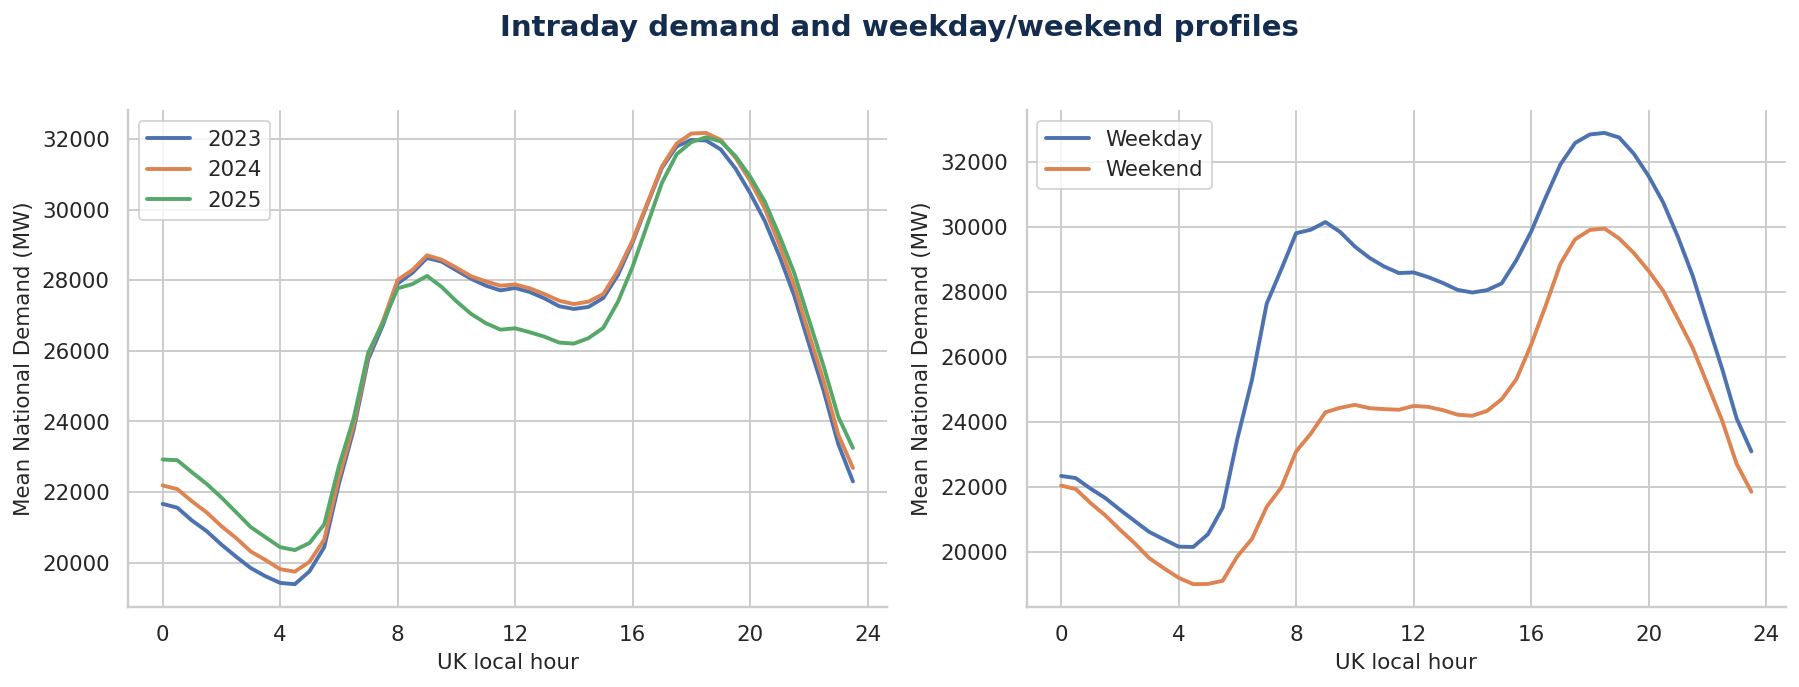

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for year, group in df.groupby('Year'):
    profile = group.groupby('ClockSlot').ActualDemandMW.mean()
    axes[0].plot(profile.index / 2, profile, label=str(year), lw=2)
for name, group in df.groupby('DayType'):
    profile = group.groupby('ClockSlot').ActualDemandMW.mean()
    axes[1].plot(profile.index / 2, profile, label=name, lw=2)
for ax in axes:
    ax.set(xlabel='UK local hour', ylabel='Mean National Demand (MW)', xticks=range(0, 25, 4))
    ax.legend()
show_chart(fig, 'Intraday demand and weekday/weekend profiles')


Average demand peaks at 18:30 UK time.
Weekday demand averages 27,035 MW, compared with 23,990 MW
on weekends, a difference of 11.3%. The weekday morning
rise is also more pronounced.


I compare monthly means and the distribution of daily demand by season.
Using daily means for the box plots keeps each day as one observation.


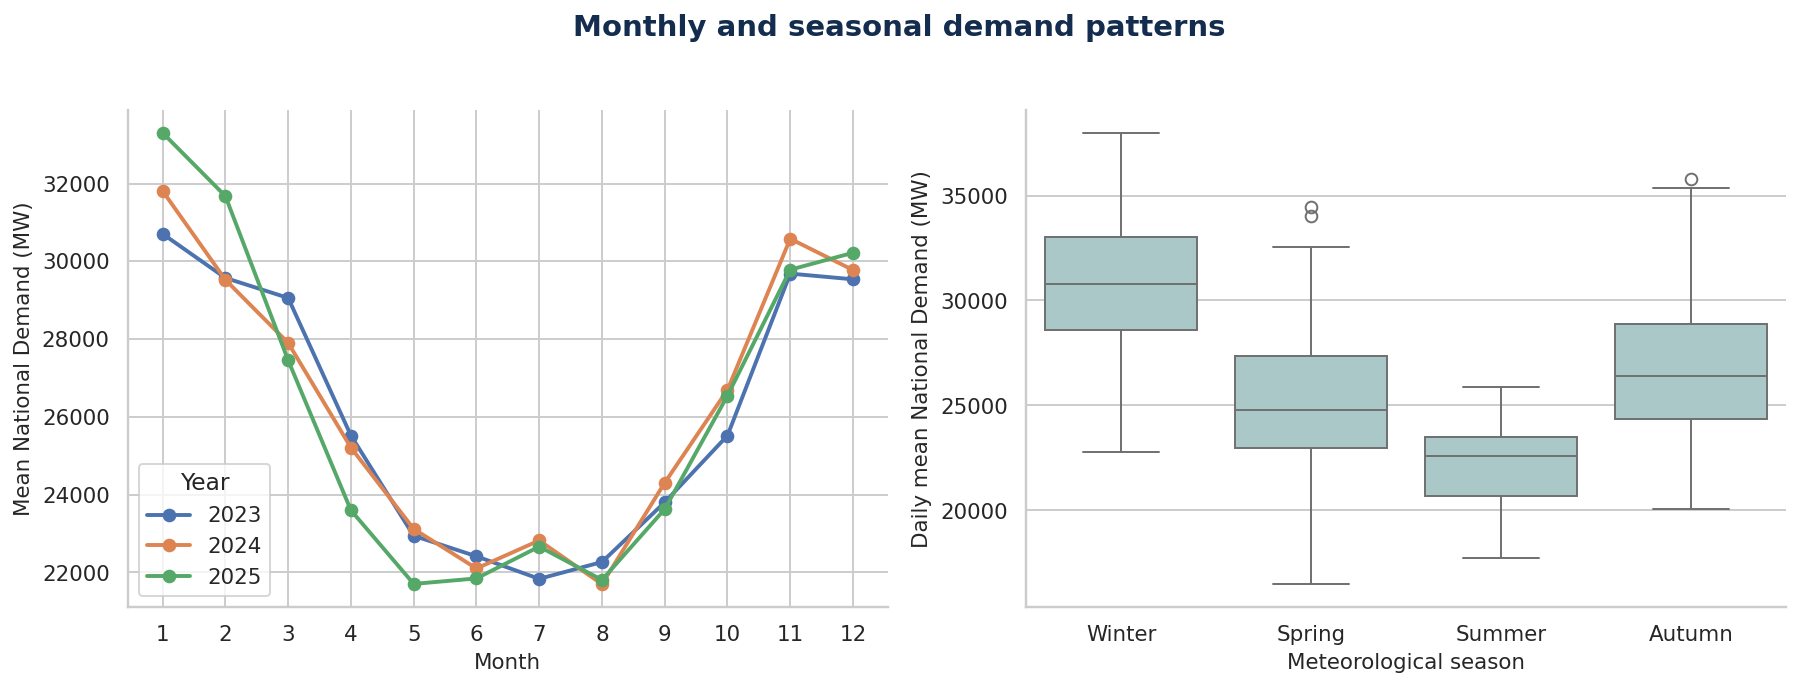

,count,mean,min,max
Season,,,,
Winter,13008,"30,691.170",15465,45924
Spring,13242,"25,171.970",12803,42385
Summer,13248,"22,163.640",13248,30261
Autumn,13110,"26,723.120",14965,43723


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
monthly = df.groupby(['Year', 'MonthNumber']).ActualDemandMW.mean().unstack(0)
monthly.plot(ax=axes[0], marker='o', lw=2)
axes[0].set(xlabel='Month', ylabel='Mean National Demand (MW)', xticks=range(1, 13))
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
sns.boxplot(data=daily.assign(Season=daily.index.month.map({
    12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
    6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',11:'Autumn'})),
    x='Season', y='MeanDemandMW', order=season_order, ax=axes[1], color='#a5cdcd')
axes[1].set(xlabel='Meteorological season', ylabel='Daily mean National Demand (MW)')
show_chart(fig, 'Monthly and seasonal demand patterns')
show_table(df.groupby('Season').ActualDemandMW.agg(['count','mean','min','max']).reindex(season_order))


Winter has the highest seasonal mean at 30,691 MW,
while summer averages 22,164 MW. The monthly curves
show a similar seasonal shape across years.


I use a weekday-by-time heatmap to examine the weekly pattern and a demand
histogram to compare the overall distributions across years.


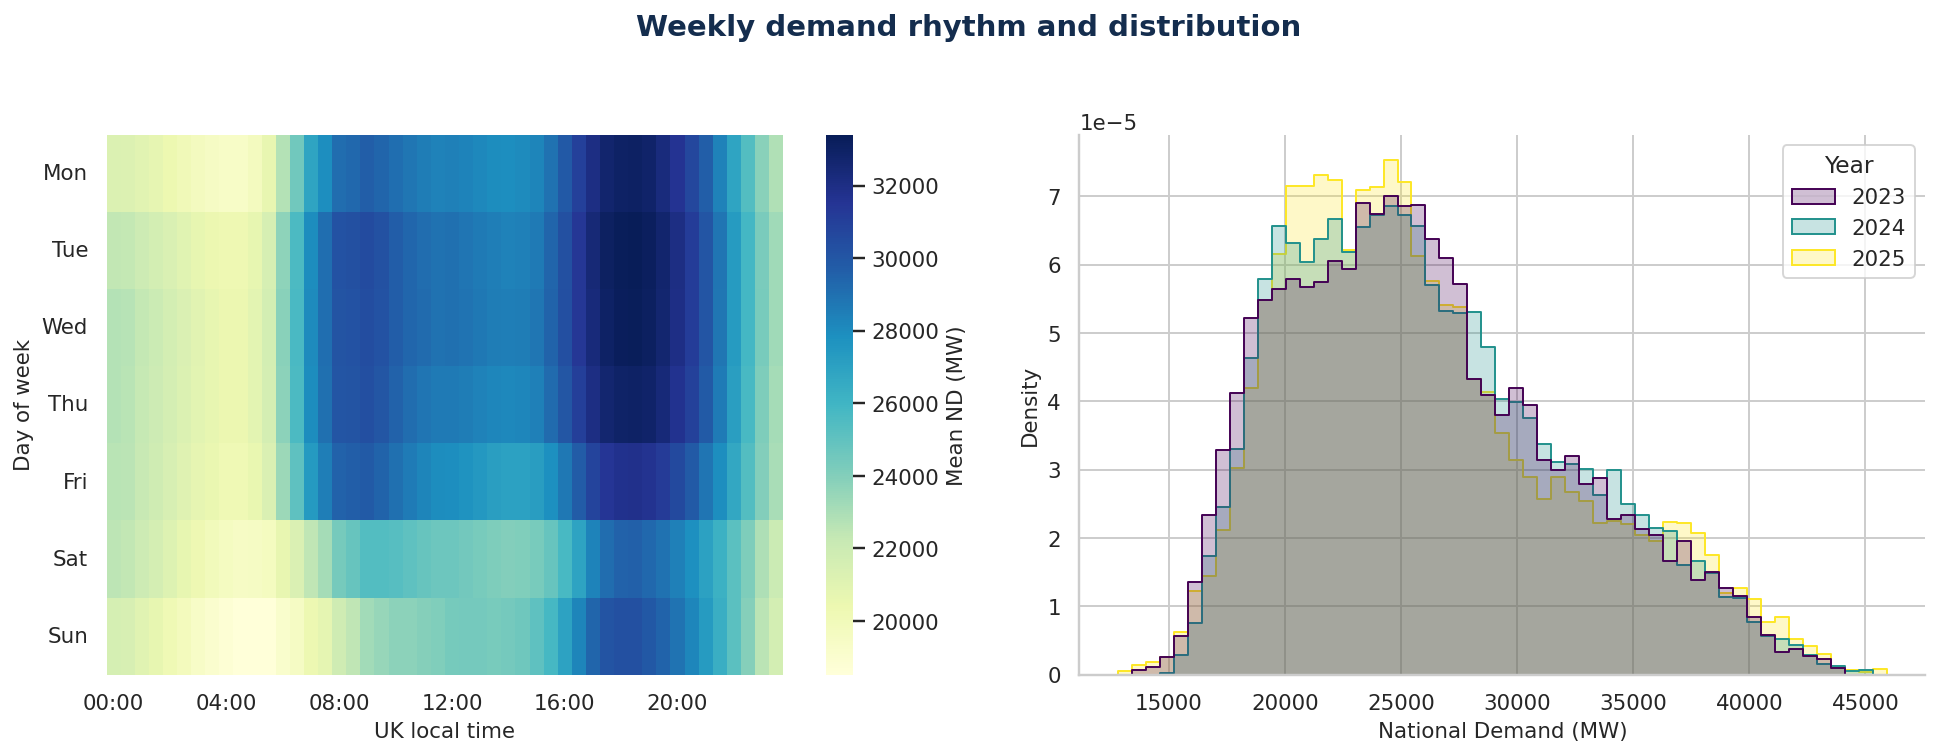

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
heat = df.pivot_table(index='DayOfWeekNumber', columns='ClockSlot', values='ActualDemandMW', aggfunc='mean')
sns.heatmap(heat, cmap='YlGnBu', ax=axes[0], cbar_kws={'label':'Mean ND (MW)'})
axes[0].set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
axes[0].set_xticks(np.arange(0, 48, 8) + .5)
axes[0].set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 4)], rotation=0)
axes[0].set(xlabel='UK local time', ylabel='Day of week')
sns.histplot(data=df, x='ActualDemandMW', hue='Year', element='step',
             stat='density', common_norm=False, bins=55, ax=axes[1], palette='viridis')
axes[1].set(xlabel='National Demand (MW)', ylabel='Density')
show_chart(fig, 'Weekly demand rhythm and distribution')


The heatmap shows the strongest demand during weekday daytime and evening
periods. The distributions overlap substantially across the three years,
although their individual peaks and tails differ.


I examine correlations between demand and observed system variables, then
plot the average embedded wind and solar profiles. These are descriptive
comparisons; realised target-day values will not enter the forecast models.


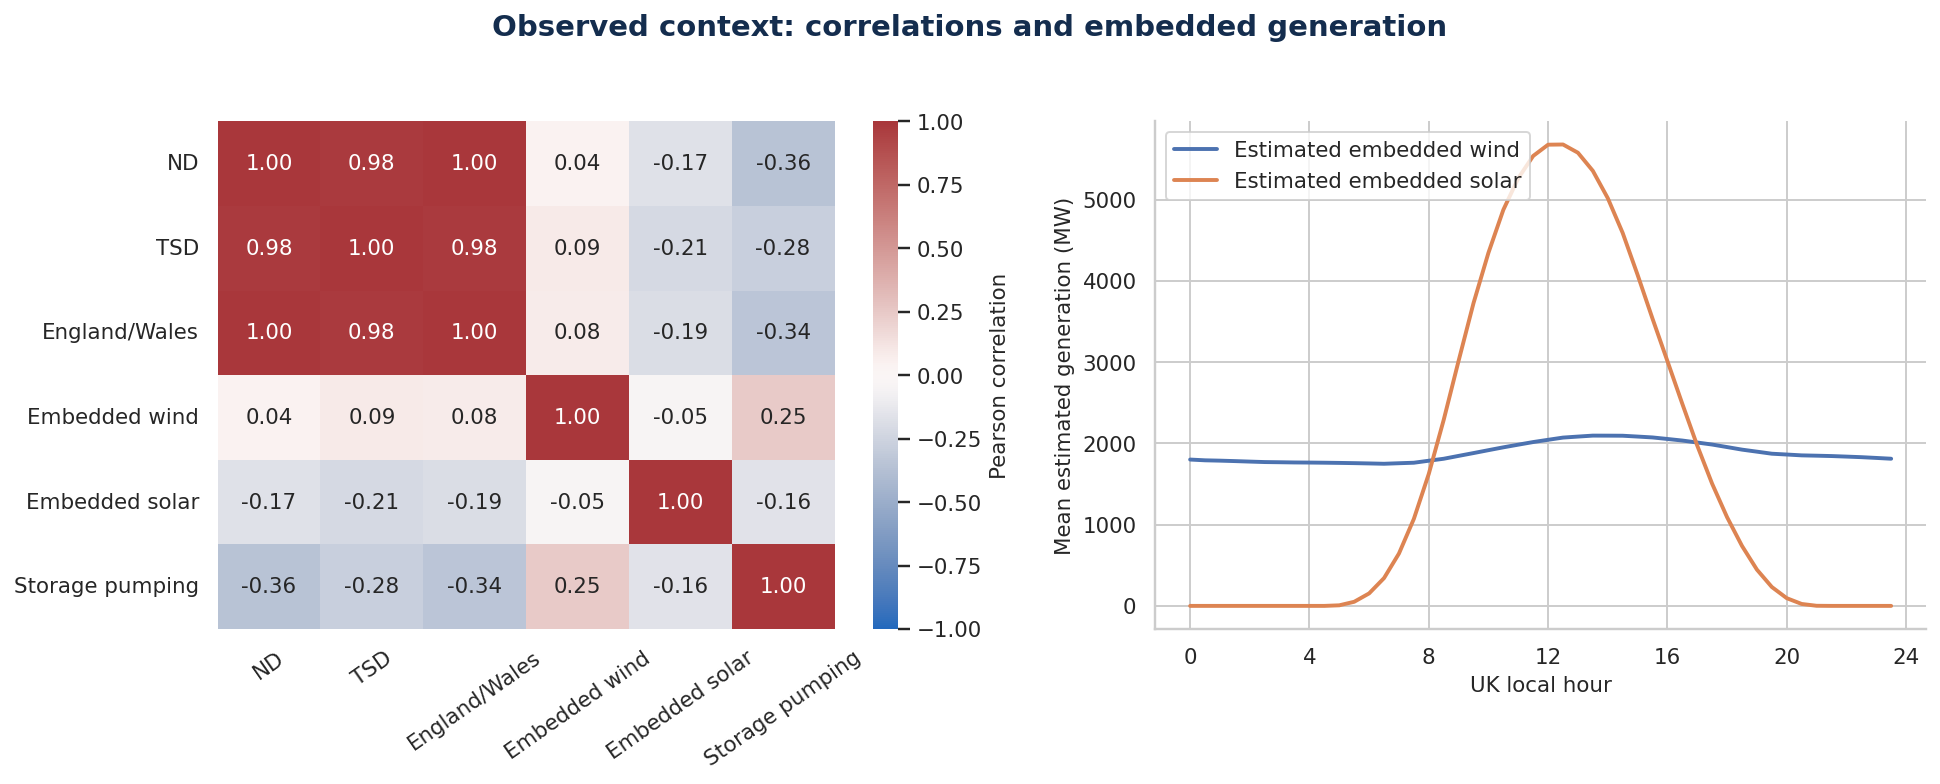

In [10]:
context_cols = ['ActualDemandMW', 'TSD', 'ENGLAND_WALES_DEMAND',
                'EMBEDDED_WIND_GENERATION', 'EMBEDDED_SOLAR_GENERATION',
                'PUMP_STORAGE_PUMPING']
fig, axes = plt.subplots(1, 2, figsize=(14, 5.7))
short_names = {'ActualDemandMW':'ND', 'ENGLAND_WALES_DEMAND':'England/Wales',
               'EMBEDDED_WIND_GENERATION':'Embedded wind', 'EMBEDDED_SOLAR_GENERATION':'Embedded solar',
               'PUMP_STORAGE_PUMPING':'Storage pumping'}
sns.heatmap(df[context_cols].rename(columns=short_names).corr(), annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap='vlag', ax=axes[0], cbar_kws={'label':'Pearson correlation'})
axes[0].tick_params(axis='x', rotation=35)
embedded = df.groupby('ClockSlot')[['EMBEDDED_WIND_GENERATION','EMBEDDED_SOLAR_GENERATION']].mean()
axes[1].plot(embedded.index / 2, embedded.EMBEDDED_WIND_GENERATION, label='Estimated embedded wind', lw=2)
axes[1].plot(embedded.index / 2, embedded.EMBEDDED_SOLAR_GENERATION, label='Estimated embedded solar', lw=2)
axes[1].set(xlabel='UK local hour', ylabel='Mean estimated generation (MW)', xticks=range(0,25,4))
axes[1].legend()
show_chart(fig, 'Observed context: correlations and embedded generation')


ND moves closely with TSD and England/Wales demand. Its correlation with
embedded solar is negative, while the overall wind correlation is small.
Time of day and season affect these relationships, so I do not interpret
the correlations as evidence of a cause.


I calculate autocorrelation over seven elapsed days on the UTC timeline.
This checks whether demand persists at daily and weekly intervals.


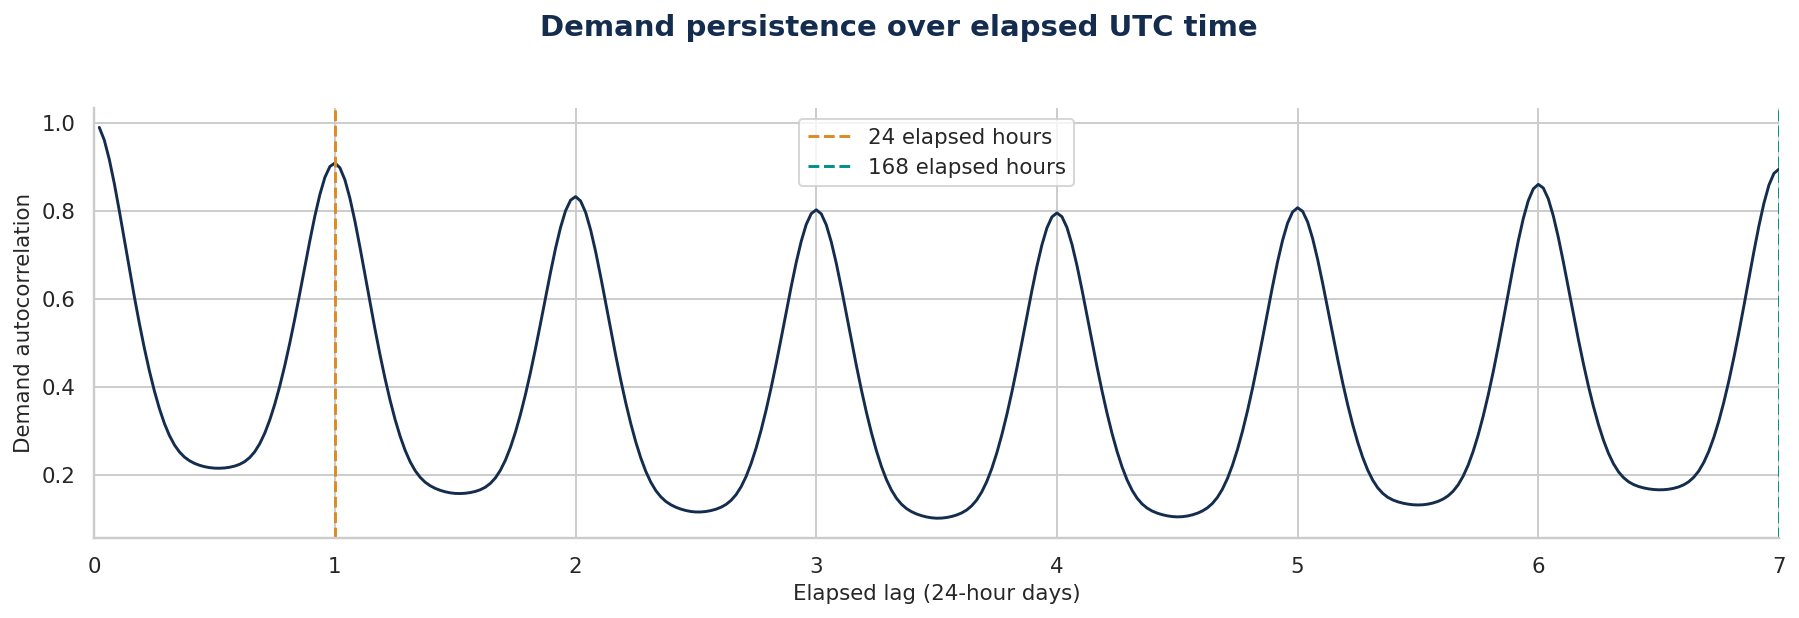

These UTC-lag correlations are exploratory. The forecast baseline aligns local clock time.


In [11]:
lags = np.arange(1, 337)
autocorr = pd.Series({int(lag): df.ActualDemandMW.autocorr(lag=int(lag)) for lag in lags})
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(autocorr.index / 48, autocorr.values, color=COLORS['Actual'])
ax.axvline(1, color='#db8b22', ls='--', label='24 elapsed hours')
ax.axvline(7, color='#008f88', ls='--', label='168 elapsed hours')
ax.set(xlabel='Elapsed lag (24-hour days)', ylabel='Demand autocorrelation', xlim=(0,7))
ax.legend()
show_chart(fig, 'Demand persistence over elapsed UTC time')
print('These UTC-lag correlations are exploratory. The forecast baseline aligns local clock time.')


Autocorrelation rises around 24-hour multiples and again at a weekly lag.
This supports testing historical demand features and a previous-week baseline.
The baseline itself will use local clock time rather than a fixed UTC shift.


## 4. Build historical features
I create demand lags at the same local time 2, 7, 14, 21 and 28 days earlier,
together with calendar fields and the mean and peak from two days earlier.

For a repeated autumn clock time, I average its two historical readings.
If the reference spring day has no matching 01:00 or 01:30 slot, I use the
mean of the neighbouring 00:30 and 02:00 readings. Other unavailable lags
remain missing.

I assume forecasts are issued at 16:00 UK time on the previous day. The
demand features are at least two calendar days old. I reserve 31 December
2023 and 2024 as embargo days so fitting and selection finish before the
first forecast of the next year is issued.


In [12]:
local_profiles = df.pivot_table(index='SettlementDate', columns='ClockSlot',
                                values='ActualDemandMW', aggfunc='mean').reindex(columns=range(48))
day_expected = df.groupby('SettlementDate').ExpectedPeriodsDay.first()
spring_dates = day_expected.index[day_expected.eq(46)]
clock_fill = local_profiles.copy()
for date in spring_dates:
    neighbour_mean = clock_fill.loc[date, [1,4]].mean(skipna=False)
    for slot in (2,3):
        if pd.isna(clock_fill.loc[date, slot]):
            clock_fill.loc[date, slot] = neighbour_mean
profile_lookup = clock_fill.stack(future_stack=True)

for lag in (2,7,14,21,28):
    lag_dates = df.SettlementDate - pd.Timedelta(days=lag)
    lookup_keys = pd.MultiIndex.from_arrays([lag_dates, df.ClockSlot])
    df[f'Lag{lag}DaysMW'] = profile_lookup.reindex(lookup_keys).to_numpy()
    if lag == 7:
        baseline_rule = pd.Series('Exact local-clock slot', index=df.index)
        baseline_rule.loc[(lag_dates.isin(spring_dates)) & df.ClockSlot.isin([2,3])] = 'Spring missing slot: neighbour mean'
        baseline_rule.loc[(lag_dates.isin(day_expected.index[day_expected.eq(50)])) & df.ClockSlot.isin([2,3])] = 'Autumn repeated slot: mean'
        baseline_rule.loc[df.Lag7DaysMW.isna()] = 'No matching historical demand'
        df['BaselineAlignmentRule'] = baseline_rule

daily_lookup = df.groupby('SettlementDate').ActualDemandMW.agg(['mean','max'])
lag2dates = df.SettlementDate - pd.Timedelta(days=2)
df['DailyMeanLag2MW'] = lag2dates.map(daily_lookup['mean'])
df['DailyPeakLag2MW'] = lag2dates.map(daily_lookup['max'])
df['WeeklyLagMeanMW'] = df[[f'Lag{lag}DaysMW' for lag in (7,14,21,28)]].mean(axis=1)
df['DayOfYearSin'] = np.sin(2 * np.pi * (df.SettlementDate.dt.dayofyear - 1) / 365.25)
df['DayOfYearCos'] = np.cos(2 * np.pi * (df.SettlementDate.dt.dayofyear - 1) / 365.25)
issue_naive = df.SettlementDate - pd.Timedelta(days=1) + pd.Timedelta(hours=16)
df['ForecastIssueLocal'] = issue_naive.dt.tz_localize(TZ)
df['ForecastIssueUTC'] = df.ForecastIssueLocal.dt.tz_convert('UTC')
latest_feature_end = (df.SettlementDate - pd.Timedelta(days=1)).dt.tz_localize(TZ).dt.tz_convert('UTC')
df['LatestFeatureEndUTC'] = latest_feature_end
assert (df.LatestFeatureEndUTC < df.ForecastIssueUTC).all()
assert (df.ForecastIssueUTC < df.UTCStart).all()
lag_cols = [f'Lag{lag}DaysMW' for lag in (2,7,14,21,28)]
df['ModelEligibleFlag'] = (df.ActualDemandMW.notna() & df[lag_cols].notna().all(axis=1)).astype(int)
df['EvaluationSplit'] = np.select(
    [df.SettlementDate.le(TRAIN_END),
     df.SettlementDate.between('2024-01-01', VALIDATION_END),
     df.SettlementDate.between('2025-01-01', TEST_END)],
    ['Train', 'Validation', 'Test'], default='Embargo')
feature_cols = ['ClockSlot','DayOfWeekNumber','MonthNumber','DayOfYearSin','DayOfYearCos',
                'IsBST','IsBankHolidayEW','IsChristmasPeriod','ExpectedPeriodsDay',
                *lag_cols,'DailyMeanLag2MW','DailyPeakLag2MW','WeeklyLagMeanMW']
X = df[feature_cols].copy()
y = df.ActualDemandMW.copy()
train_mask = df.EvaluationSplit.eq('Train') & df.ModelEligibleFlag.eq(1)
val_mask = df.EvaluationSplit.eq('Validation') & df.ModelEligibleFlag.eq(1)
test_mask = df.EvaluationSplit.eq('Test') & df.ModelEligibleFlag.eq(1)
show_table(df.groupby('EvaluationSplit').agg(
    FirstDate=('SettlementDate','min'), LastDate=('SettlementDate','max'),
    Rows=('IntervalID','size'), Eligible=('ModelEligibleFlag','sum'))
    .reindex(['Train','Validation','Test','Embargo']))
show_table(df.loc[val_mask, ['SettlementDate','ClockTime','ForecastIssueUTC',
                            'LatestFeatureEndUTC',*lag_cols]].head())
assert (df.loc[train_mask,'UTCStart'].max() + pd.Timedelta(minutes=30)
        < df.loc[val_mask,'ForecastIssueUTC'].min())
assert (df.loc[train_mask | val_mask,'UTCStart'].max() + pd.Timedelta(minutes=30)
        < df.loc[test_mask,'ForecastIssueUTC'].min())
print('Feature and model-training availability ordering passed. Realised target-day context is excluded from X.')


,FirstDate,LastDate,Rows,Eligible
EvaluationSplit,,,,
Train,2023-01-01,2023-12-30,17472,16128
Validation,2024-01-01,2024-12-30,17520,17520
Test,2025-01-01,2025-12-31,17520,17520
Embargo,2023-12-31,2024-12-31,96,96


,SettlementDate,ClockTime,ForecastIssueUTC,LatestFeatureEndUTC,Lag2DaysMW,Lag7DaysMW,Lag14DaysMW,Lag21DaysMW,Lag28DaysMW
17520,2024-01-01,00:00,2023-12-31 16:00:00+00:00,2023-12-31 00:00:00+00:00,"22,718.000","18,794.000","21,781.000","23,049.000","25,349.000"
17521,2024-01-01,00:30,2023-12-31 16:00:00+00:00,2023-12-31 00:00:00+00:00,"23,261.000","19,097.000","22,182.000","23,472.000","26,138.000"
17522,2024-01-01,01:00,2023-12-31 16:00:00+00:00,2023-12-31 00:00:00+00:00,"23,088.000","18,953.000","22,017.000","23,093.000","25,887.000"
17523,2024-01-01,01:30,2023-12-31 16:00:00+00:00,2023-12-31 00:00:00+00:00,"22,579.000","18,649.000","21,578.000","22,474.000","25,334.000"
17524,2024-01-01,02:00,2023-12-31 16:00:00+00:00,2023-12-31 00:00:00+00:00,"22,246.000","18,151.000","21,369.000","22,027.000","24,949.000"


Feature and model-training availability ordering passed. Realised target-day context is excluded from X.


After the initial 28-day warm-up, 16,128 training intervals are eligible.
Validation and test each have 17,520 eligible intervals. The timestamp
checks confirm that the observations used for features and fitting end
before the assumed issue time.


## 5. Train and select the models
I compare the local-time seasonal baseline with ridge regression and
histogram gradient boosting. Ridge uses one-hot calendar fields, scaled
numerical features and median imputation fitted on training data.
Gradient boosting captures nonlinear relationships between the features.

I compare three settings for each fitted algorithm using 2024 MAE.
Random internal early stopping is disabled for gradient boosting, keeping
validation chronological. Signed error is prediction minus actual demand.


In [13]:
def score_predictions(actual, prediction):
    actual, prediction = np.asarray(actual, dtype=float), np.asarray(prediction, dtype=float)
    good = np.isfinite(actual) & np.isfinite(prediction)
    if not good.any():
        return {'N':0,'MAE_MW':np.nan,'RMSE_MW':np.nan,'Bias_MW':np.nan,'WAPE_Pct':np.nan}
    error = prediction[good] - actual[good]
    denominator = np.abs(actual[good]).sum()
    return {'N':int(good.sum()), 'MAE_MW':float(np.abs(error).mean()),
            'RMSE_MW':float(np.sqrt(np.mean(error**2))), 'Bias_MW':float(error.mean()),
            'WAPE_Pct':float(100*np.abs(error).sum()/denominator) if denominator else np.nan}

categorical_cols = ['ClockSlot','DayOfWeekNumber','MonthNumber']
numerical_cols = [column for column in feature_cols if column not in categorical_cols]

def make_ridge(alpha):
    preprocessing = ColumnTransformer([
        ('calendar', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('numeric', Pipeline([('imputer',SimpleImputer(strategy='median')),
                              ('scaler',StandardScaler())]), numerical_cols),
    ])
    return Pipeline([('preprocess',preprocessing), ('regressor',Ridge(alpha=alpha))])

def make_boosting(parameters):
    return HistGradientBoostingRegressor(
        loss='squared_error', early_stopping=False, random_state=SEED, **parameters)

validation_predictions = {'Seasonal naive': df.loc[val_mask,'Lag7DaysMW'].to_numpy()}
tuning_rows, fitted_candidates = [], {}
for alpha in (1.0, 100.0, 1000.0):
    model = make_ridge(alpha)
    start = time.perf_counter()
    model.fit(X.loc[train_mask], y.loc[train_mask])
    prediction = model.predict(X.loc[val_mask])
    key = f'Ridge alpha={alpha:g}'
    fitted_candidates[key] = (model, prediction, {'alpha':alpha})
    tuning_rows.append({'Algorithm':'Ridge','Candidate':key,
                        **score_predictions(y.loc[val_mask],prediction),
                        'FitSeconds':time.perf_counter()-start})

boosting_grid = [
    {'learning_rate':0.05,'max_iter':180,'max_leaf_nodes':15,'min_samples_leaf':60,'l2_regularization':5.0},
    {'learning_rate':0.05,'max_iter':240,'max_leaf_nodes':31,'min_samples_leaf':40,'l2_regularization':5.0},
    {'learning_rate':0.08,'max_iter':200,'max_leaf_nodes':31,'min_samples_leaf':60,'l2_regularization':10.0},
]
for i, parameters in enumerate(boosting_grid, start=1):
    model = make_boosting(parameters)
    start = time.perf_counter()
    model.fit(X.loc[train_mask], y.loc[train_mask])
    prediction = model.predict(X.loc[val_mask])
    key = f'Gradient boosting {i}'
    fitted_candidates[key] = (model,prediction,parameters)
    tuning_rows.append({'Algorithm':'Gradient boosting','Candidate':key,
                        **score_predictions(y.loc[val_mask],prediction),
                        'FitSeconds':time.perf_counter()-start})

tuning = pd.DataFrame(tuning_rows).sort_values(['Algorithm','MAE_MW'])
best_ridge_key = tuning.loc[tuning.Algorithm.eq('Ridge')].sort_values('MAE_MW').Candidate.iloc[0]
best_boost_key = tuning.loc[tuning.Algorithm.eq('Gradient boosting')].sort_values('MAE_MW').Candidate.iloc[0]
selected_parameters = {
    'Ridge':fitted_candidates[best_ridge_key][2],
    'Gradient boosting':fitted_candidates[best_boost_key][2],
}
validation_models = {
    'Ridge':fitted_candidates[best_ridge_key][0],
    'Gradient boosting':fitted_candidates[best_boost_key][0],
}
validation_predictions['Ridge'] = fitted_candidates[best_ridge_key][1]
validation_predictions['Gradient boosting'] = fitted_candidates[best_boost_key][1]
validation_scores = pd.DataFrame([
    {'Model':name, **score_predictions(y.loc[val_mask],prediction)}
    for name,prediction in validation_predictions.items()
]).sort_values('MAE_MW')
selected_method = validation_scores.Model.iloc[0]
show_table(tuning)
show_table(validation_scores)
print('Frozen hyperparameters:', json.dumps(selected_parameters, indent=2))
print('Preferred method selected on 2024 MAE:', selected_method)


,Algorithm,Candidate,N,MAE_MW,RMSE_MW,Bias_MW,WAPE_Pct,FitSeconds
4,Gradient boosting,Gradient boosting 2,17520,"1,654.460","2,246.430",-372.320,6.290,0.700
3,Gradient boosting,Gradient boosting 1,17520,"1,668.230","2,288.710",-418.080,6.350,0.410
5,Gradient boosting,Gradient boosting 3,17520,"1,701.180","2,324.550",-425.900,6.470,0.720
2,Ridge,Ridge alpha=1000,17520,"1,542.840","2,035.900",-210.400,5.870,0.040
1,Ridge,Ridge alpha=100,17520,"1,580.220","2,096.680",-272.410,6.010,0.050
0,Ridge,Ridge alpha=1,17520,"1,641.750","2,189.850",-324.390,6.240,0.050


,Model,N,MAE_MW,RMSE_MW,Bias_MW,WAPE_Pct
1,Ridge,17520,"1,542.840","2,035.900",-210.400,5.870
2,Gradient boosting,17520,"1,654.460","2,246.430",-372.320,6.290
0,Seasonal naive,17520,"2,009.630","2,676.650",-31.850,7.640


Frozen hyperparameters: {
  "Ridge": {
    "alpha": 1000.0
  },
  "Gradient boosting": {
    "learning_rate": 0.05,
    "max_iter": 240,
    "max_leaf_nodes": 31,
    "min_samples_leaf": 40,
    "l2_regularization": 5.0
  }
}
Preferred method selected on 2024 MAE: Ridge


Ridge with `alpha = 1000` gives the lowest validation MAE. The best boosting
configuration uses 240 iterations, 31 leaf nodes and a learning rate of 0.05.
I select ridge as the preferred method before examining the test results.


I plot validation MAE and RMSE to compare the selected settings with the
seasonal baseline. Both metrics use the same set of intervals.


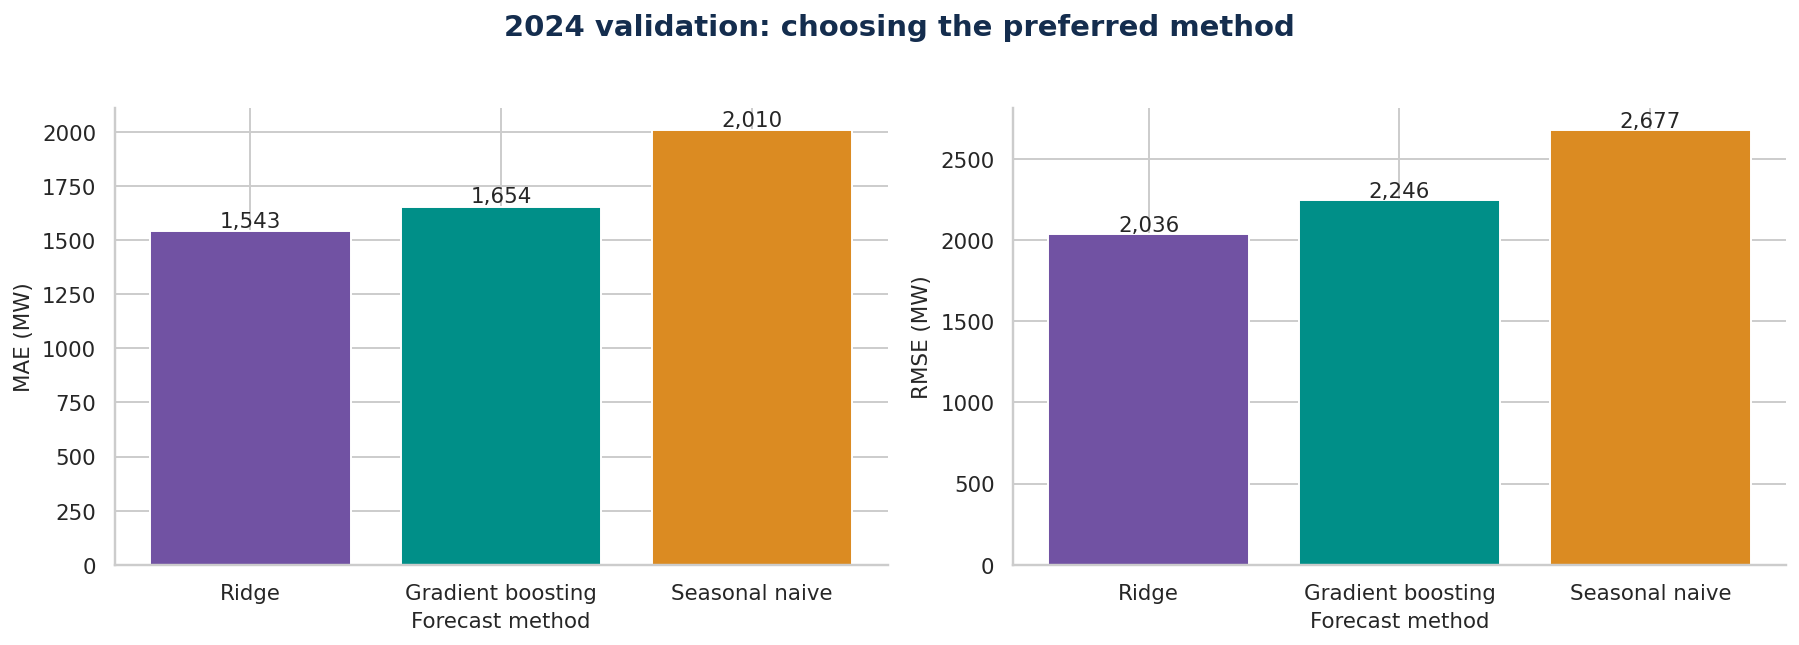

In [14]:
fig, axes = plt.subplots(1,2,figsize=(13,4.7))
for ax, metric, title in zip(axes,['MAE_MW','RMSE_MW'],['MAE','RMSE']):
    ordered = validation_scores
    ax.bar(ordered.Model,ordered[metric],color=[COLORS[n] for n in ordered.Model])
    ax.set(ylabel=f'{title} (MW)',xlabel='Forecast method')
    for i,value in enumerate(ordered[metric]):
        ax.text(i,value+20,f'{value:,.0f}',ha='center')
show_chart(fig,'2024 validation: choosing the preferred method')


Ridge's validation MAE is about 1,543 MW, compared with 2,010 MW for the
seasonal baseline, an improvement of 23.2%. Its validation RMSE is also
lower than both the baseline and gradient boosting.


## 6. Evaluate on 2025
I refit the tuned models on eligible 2023–2024 observations and forecast
the held-out 2025 intervals. The parameters and preferred method remain
fixed. Earlier observations become available for lag features as the
test year progresses.


In [15]:
refit_mask = train_mask | val_mask
final_models = {
    'Ridge':make_ridge(selected_parameters['Ridge']['alpha']),
    'Gradient boosting':make_boosting(selected_parameters['Gradient boosting']),
}
test_predictions = {'Seasonal naive':df.loc[test_mask,'Lag7DaysMW'].to_numpy()}
for name, model in final_models.items():
    model.fit(X.loc[refit_mask],y.loc[refit_mask])
    test_predictions[name] = model.predict(X.loc[test_mask])

prediction_columns = {'Seasonal naive':'BaselineForecastMW',
                      'Ridge':'RidgeForecastMW','Gradient boosting':'BoostingForecastMW'}
for name,column in prediction_columns.items():
    df[column] = np.nan
    df.loc[val_mask,column] = validation_predictions[name]
    df.loc[test_mask,column] = test_predictions[name]
df['SelectedForecastMW'] = df[prediction_columns[selected_method]]
df['SelectedModel'] = selected_method
df['ModelTrainingEndDate'] = pd.NaT
df.loc[val_mask,'ModelTrainingEndDate'] = TRAIN_END
df.loc[test_mask,'ModelTrainingEndDate'] = VALIDATION_END
df['ForecastEvaluationFlag'] = ((val_mask | test_mask) &
                               df[list(prediction_columns.values())].notna().all(axis=1)).astype(int)

metrics = pd.DataFrame([
    {'Split':split,'Model':name,**score_predictions(df.loc[mask,'ActualDemandMW'],
                                                  df.loc[mask,column])}
    for split,mask in [('Validation',val_mask),('Test',test_mask)]
    for name,column in prediction_columns.items()
])
for split in ['Validation','Test']:
    baseline_mae = metrics.loc[metrics.Split.eq(split)&metrics.Model.eq('Seasonal naive'),'MAE_MW'].iloc[0]
    metrics.loc[metrics.Split.eq(split),'MAEImprovementVsBaselinePct'] = (
        1 - metrics.loc[metrics.Split.eq(split),'MAE_MW']/baseline_mae)*100
show_table(metrics)
print('Held-out predictions are complete for', int(test_mask.sum()), 'test intervals.')
print('No training-fit predictions are exported as forecast accuracy evidence.')


,Split,Model,N,MAE_MW,RMSE_MW,Bias_MW,WAPE_Pct,MAEImprovementVsBaselinePct
0,Validation,Seasonal naive,17520,"2,009.630","2,676.650",-31.850,7.640,0.000
1,Validation,Ridge,17520,"1,542.840","2,035.900",-210.400,5.870,23.230
2,Validation,Gradient boosting,17520,"1,654.460","2,246.430",-372.320,6.290,17.670
3,Test,Seasonal naive,17520,"2,177.540","2,920.090",-42.360,8.320,0.000
4,Test,Ridge,17520,"1,565.260","2,068.430",-44.750,5.980,28.120
5,Test,Gradient boosting,17520,"1,568.040","2,059.390",-8.460,5.990,27.990


Held-out predictions are complete for 17520 test intervals.
No training-fit predictions are exported as forecast accuracy evidence.


Ridge achieves a test MAE of 1,565 MW and RMSE of
2,068 MW, reducing MAE by 28.1% against the baseline.
Gradient boosting has a very similar test MAE and a slightly lower RMSE.
I retain ridge because the selection was based on validation performance.


I calculate signed, absolute and squared errors for each forecast method.
I use the selected method's 99th-percentile validation error as a fixed
large-error threshold, then rank deviations separately within each split.


In [16]:
error_prefixes = {'Baseline':'BaselineForecastMW','Ridge':'RidgeForecastMW',
                  'Boosting':'BoostingForecastMW','Selected':'SelectedForecastMW'}
for prefix,column in error_prefixes.items():
    df[f'{prefix}ErrorMW'] = df[column] - df.ActualDemandMW
    df[f'{prefix}AbsErrorMW'] = df[f'{prefix}ErrorMW'].abs()
    df[f'{prefix}SquaredErrorMW2'] = df[f'{prefix}ErrorMW']**2
df['SelectedErrorPct'] = 100*df.SelectedErrorMW/df.ActualDemandMW.where(df.ActualDemandMW.ne(0))
error_threshold = df.loc[val_mask,'SelectedAbsErrorMW'].quantile(.99)
df['LargeErrorThresholdMW'] = error_threshold
df['LargeErrorFlag'] = np.where(df.ForecastEvaluationFlag.eq(1),
                              df.SelectedAbsErrorMW.ge(error_threshold).astype(int),np.nan)
df['SelectedDeviationRank'] = np.nan
for split in ('Validation','Test'):
    mask = df.EvaluationSplit.eq(split) & df.ForecastEvaluationFlag.eq(1)

    df.loc[mask,'SelectedDeviationRank'] = df.loc[mask,'SelectedAbsErrorMW'].rank(
        method='first',ascending=False)
df['ErrorDirection'] = np.select(
    [df.SelectedErrorMW.gt(0),df.SelectedErrorMW.lt(0),df.SelectedErrorMW.eq(0)],
    ['Overforecast','Underforecast','Exact'], default='Not evaluated')
print(f'Large-error threshold fixed from validation 99th percentile: {error_threshold:,.0f} MW.')
print('This threshold flags unusual model errors, not verified faults or causes.')


Large-error threshold fixed from validation 99th percentile: 5,947 MW.
This threshold flags unusual model errors, not verified faults or causes.


The threshold is 5,947 MW. It flags 214 test intervals,
or 1.22% of the year. Positive signed errors mean
overforecasting and negative values mean underforecasting.


I compare overall test accuracy and plot actual demand against all three
forecasts for 13–19 January. I use a fixed example week alongside the
full-year metrics so the line chart is not selected for favourable errors.


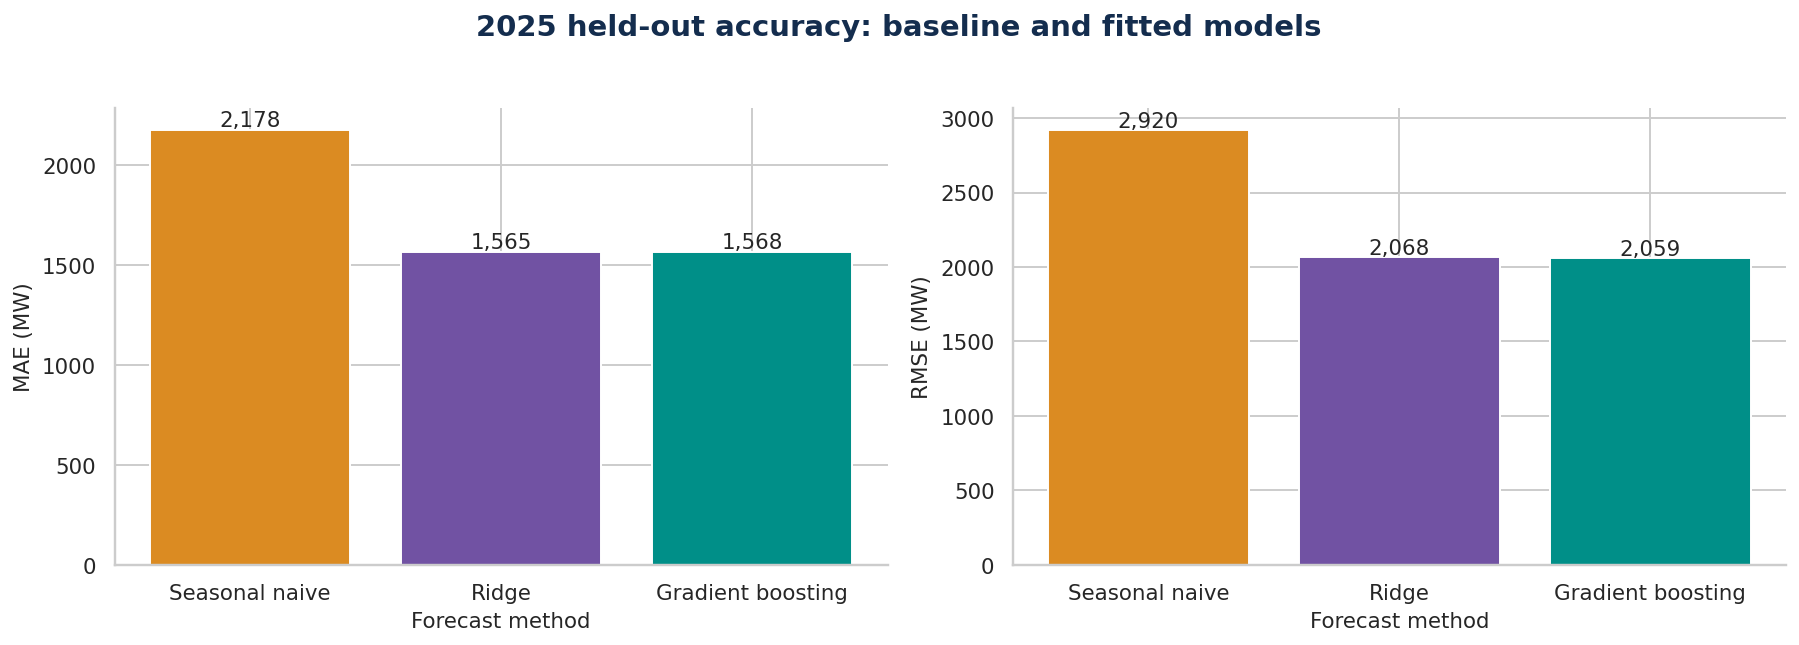

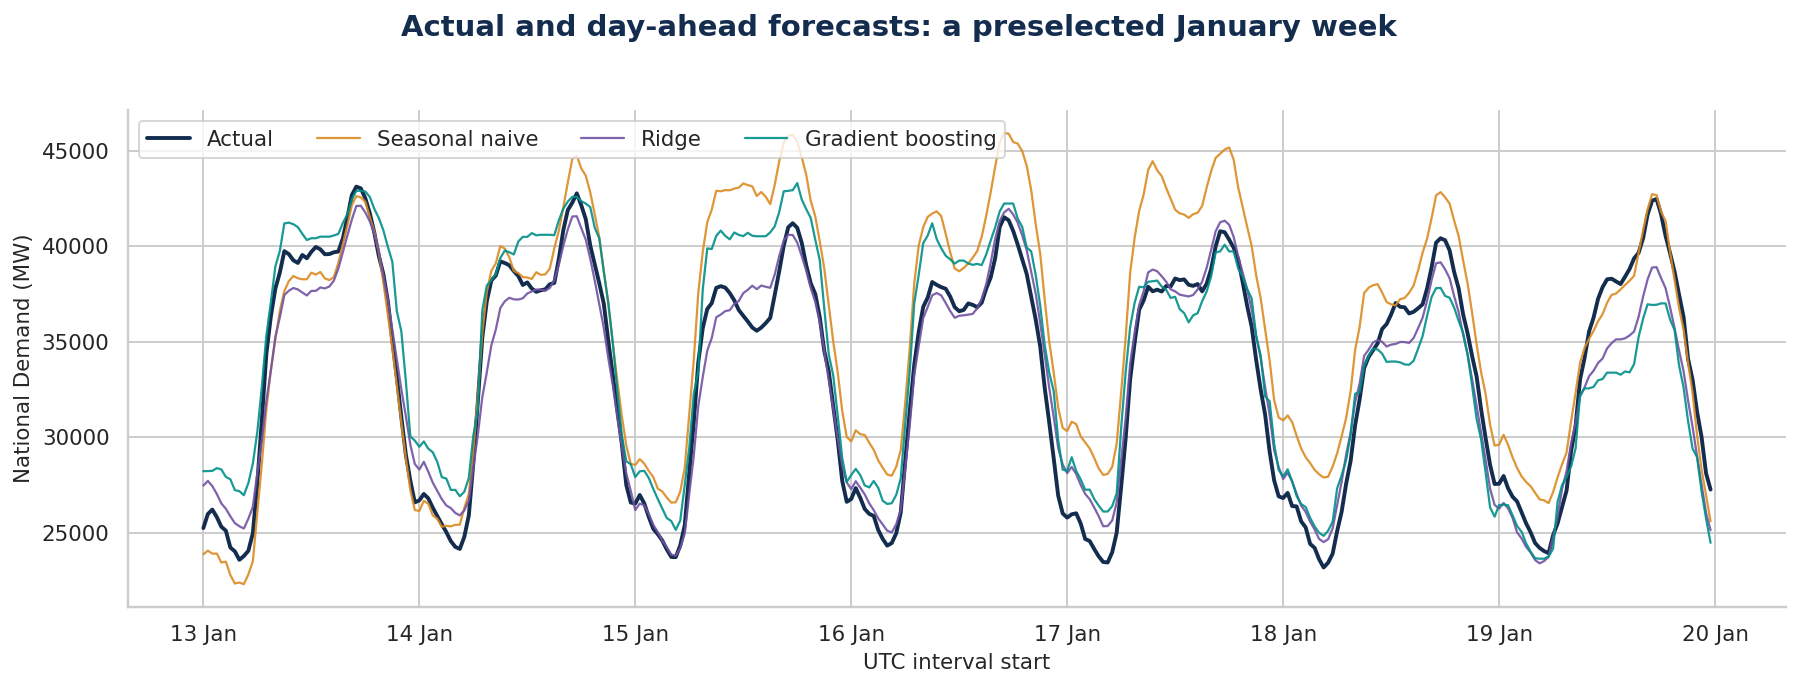

In [17]:
test_scores = metrics.loc[metrics.Split.eq('Test')]
fig,axes = plt.subplots(1,2,figsize=(13,4.7))
for ax,metric,title in zip(axes,['MAE_MW','RMSE_MW'],['MAE','RMSE']):
    ax.bar(test_scores.Model,test_scores[metric],color=[COLORS[n] for n in test_scores.Model])
    ax.set(ylabel=f'{title} (MW)',xlabel='Forecast method')
    for i,value in enumerate(test_scores[metric]):
        ax.text(i,value+20,f'{value:,.0f}',ha='center')
show_chart(fig,'2025 held-out accuracy: baseline and fitted models')

example = df.loc[df.SettlementDate.between('2025-01-13','2025-01-19')]
fig,ax = plt.subplots(figsize=(13,5))
ax.plot(example.UTCStart,example.ActualDemandMW,label='Actual',color=COLORS['Actual'],lw=2)
for name,column in prediction_columns.items():
    ax.plot(example.UTCStart,example[column],label=name,color=COLORS[name],lw=1.15,alpha=.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.set(xlabel='UTC interval start',ylabel='National Demand (MW)')
ax.legend(ncol=4,loc='upper left')
show_chart(fig,'Actual and day-ahead forecasts: a preselected January week')


Both fitted models follow the daily pattern more closely than the seasonal
baseline during this week. The differences between forecast and actual
demand are still visible around several peaks.


I plot the signed-error distributions and actual-versus-forecast agreement
for the selected method. The zero-error and diagonal lines show where
forecasts would match the observations exactly.


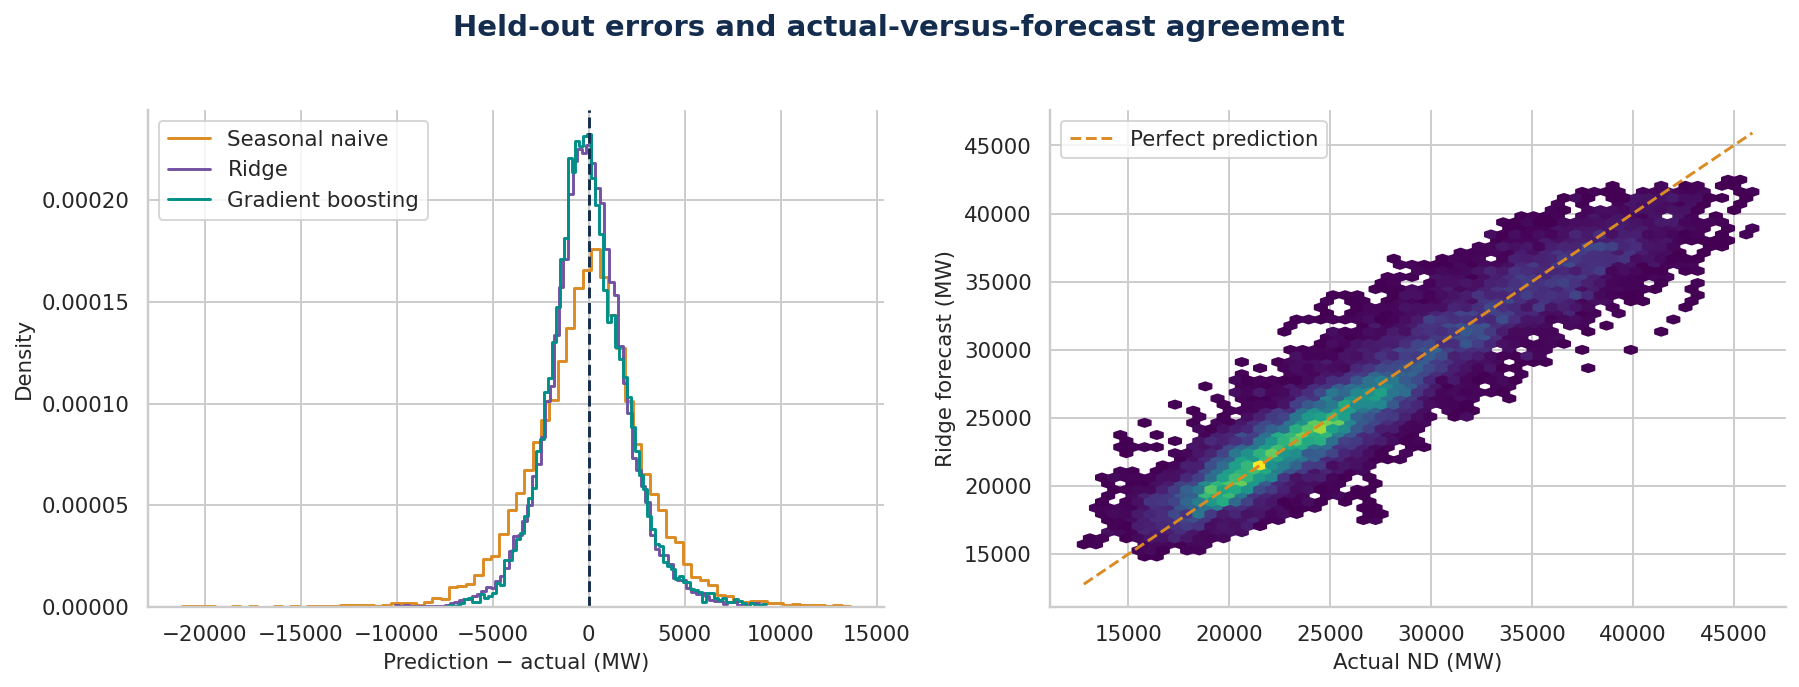

In [18]:
evaluation = df.loc[df.ForecastEvaluationFlag.eq(1)].copy()
test = evaluation.loc[evaluation.EvaluationSplit.eq('Test')].copy()
fig,axes = plt.subplots(1,2,figsize=(13,5))
for name,prefix in [('Seasonal naive','Baseline'),('Ridge','Ridge'),('Gradient boosting','Boosting')]:
    sns.histplot(test[f'{prefix}ErrorMW'],bins=80,stat='density',element='step',fill=False,
                 label=name,color=COLORS[name],ax=axes[0])
axes[0].axvline(0,color='#142d4e',ls='--')
axes[0].set(xlabel='Prediction − actual (MW)',ylabel='Density')
axes[0].legend()
axes[1].hexbin(test.ActualDemandMW,test.SelectedForecastMW,gridsize=55,mincnt=1,cmap='viridis')
limits = [min(test.ActualDemandMW.min(),test.SelectedForecastMW.min()),
          max(test.ActualDemandMW.max(),test.SelectedForecastMW.max())]
axes[1].plot(limits,limits,color='#db8b22',ls='--',label='Perfect prediction')
axes[1].set(xlabel='Actual ND (MW)',ylabel=f'{selected_method} forecast (MW)')
axes[1].legend()
show_chart(fig,'Held-out errors and actual-versus-forecast agreement')


The fitted models have narrower error distributions than the baseline.
Ridge's overall signed bias is -45 MW, although the tails
show that large underforecasts and overforecasts still occur.


I aggregate the interval errors by month to check whether accuracy and
bias remain stable through the test year. RMSE is calculated from the
mean squared interval error rather than by averaging monthly RMSE values.


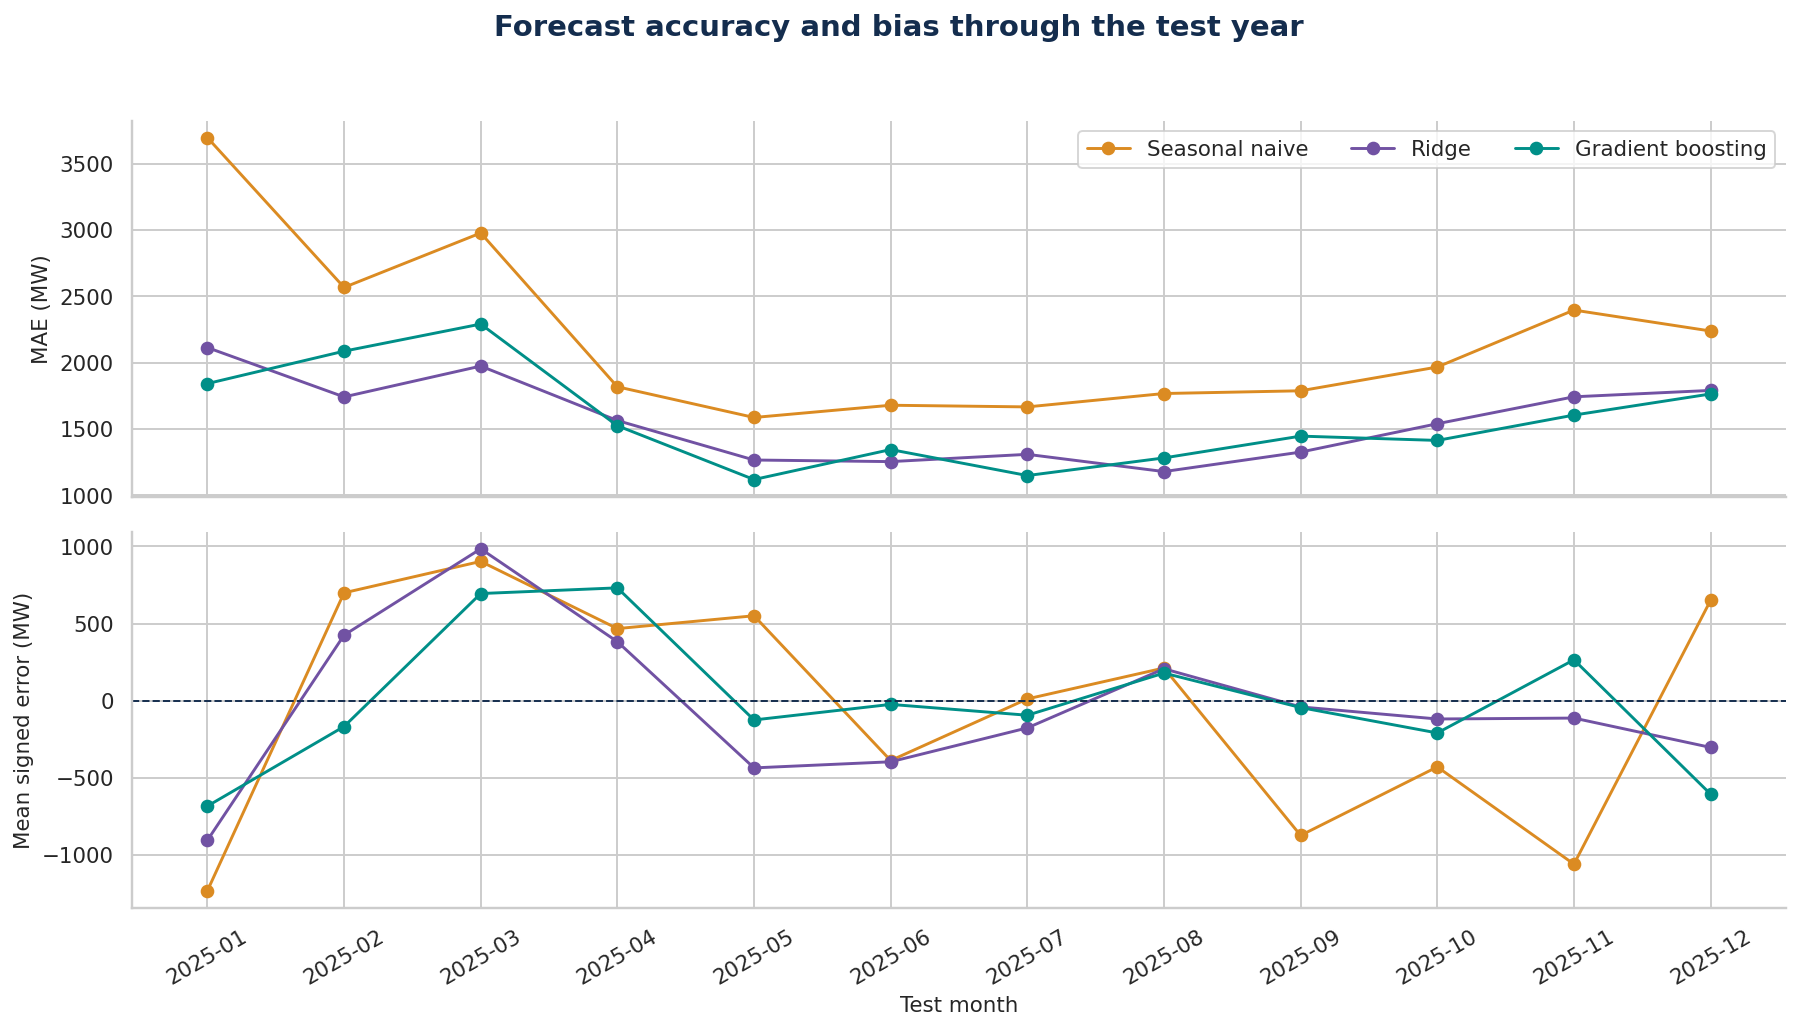

,YearMonth,Model,N,MAE_MW,RMSE_MW,Bias_MW,WAPE_Pct
1,2025-01,Ridge,1488,"2,112.630","2,707.620",-904.880,6.340
4,2025-02,Ridge,1344,"1,740.860","2,269.220",424.850,5.500
7,2025-03,Ridge,1486,"1,973.180","2,618.010",984.400,7.190
10,2025-04,Ridge,1440,"1,562.690","2,117.660",382.380,6.620
13,2025-05,Ridge,1488,"1,265.180","1,715.380",-435.720,5.830
16,2025-06,Ridge,1440,"1,253.160","1,590.900",-396.160,5.740
19,2025-07,Ridge,1488,"1,307.950","1,662.520",-176.410,5.770
22,2025-08,Ridge,1488,"1,178.000","1,640.110",206.750,5.400
25,2025-09,Ridge,1440,"1,324.840","1,744.880",-40.360,5.610
28,2025-10,Ridge,1490,"1,538.620","1,933.850",-118.680,5.800


In [19]:
monthly_metrics_rows=[]
for month,part in test.groupby('YearMonth'):
    for name,column in prediction_columns.items():
        monthly_metrics_rows.append({'YearMonth':month,'Model':name,
                                     **score_predictions(part.ActualDemandMW,part[column])})
monthly_metrics=pd.DataFrame(monthly_metrics_rows)
fig,axes=plt.subplots(2,1,figsize=(13,7.5),sharex=True)
for name in prediction_columns:
    part=monthly_metrics.loc[monthly_metrics.Model.eq(name)]
    axes[0].plot(part.YearMonth,part.MAE_MW,marker='o',label=name,color=COLORS[name])
    axes[1].plot(part.YearMonth,part.Bias_MW,marker='o',label=name,color=COLORS[name])
axes[0].set(ylabel='MAE (MW)')
axes[0].legend(ncol=3)
axes[1].axhline(0,color='#142d4e',ls='--',lw=1)
axes[1].set(ylabel='Mean signed error (MW)',xlabel='Test month')
axes[1].tick_params(axis='x',rotation=30)
show_chart(fig,'Forecast accuracy and bias through the test year')
show_table(monthly_metrics.loc[monthly_metrics.Model.eq(selected_method)])


Ridge's monthly MAE is highest in 2025-01 at
2,113 MW and lowest in 2025-08 at
1,178 MW. Monthly bias changes direction, which the
small full-year mean bias does not show on its own.


## 7. Investigate errors and feature importance
I estimate gradient-boosting permutation importance on 2,500 validation
observations, repeating each shuffle three times. The change in MAE
indicates how much the model relies on each feature in this sample.


,Feature,MAEIncreaseMW,StdMW
16,WeeklyLagMeanMW,"1,802.180",34.460
9,Lag2DaysMW,422.760,11.270
10,Lag7DaysMW,396.420,19.150
11,Lag14DaysMW,156.710,6.240
4,DayOfYearCos,137.840,7.900
1,DayOfWeekNumber,133.690,11.320
3,DayOfYearSin,106.180,7.360
0,ClockSlot,101.250,3.200
15,DailyPeakLag2MW,50.990,2.830
13,Lag28DaysMW,36.360,2.530


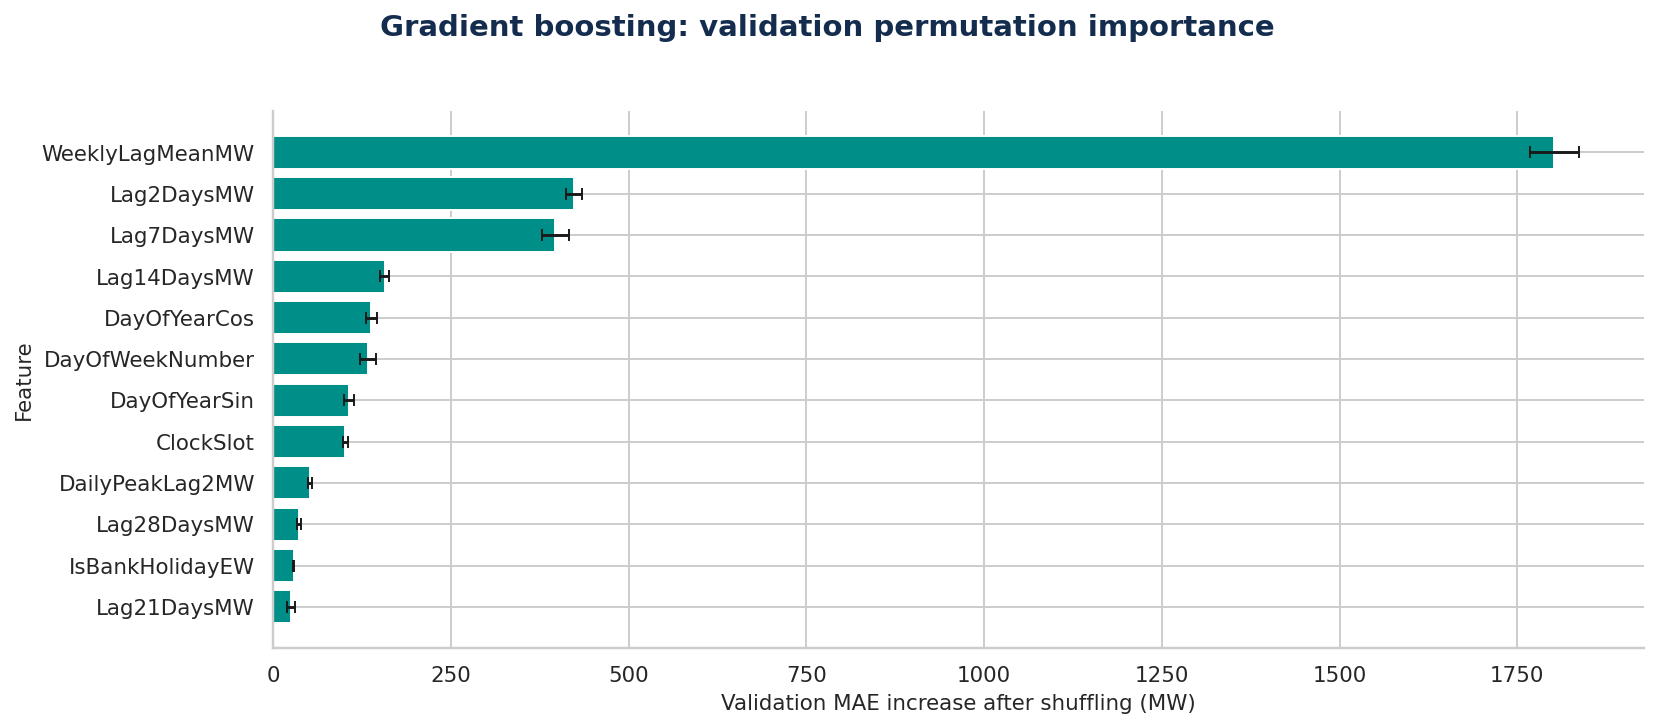

In [20]:
sample = X.loc[val_mask].sample(n=min(2500,int(val_mask.sum())),random_state=SEED)
importance = permutation_importance(validation_models['Gradient boosting'],sample,y.loc[sample.index],
                                     scoring='neg_mean_absolute_error',n_repeats=3,
                                     random_state=SEED,n_jobs=1)
importance_table=pd.DataFrame({'Feature':feature_cols,'MAEIncreaseMW':importance.importances_mean,
                               'StdMW':importance.importances_std}).sort_values('MAEIncreaseMW',ascending=False)
show_table(importance_table)
fig,ax=plt.subplots(figsize=(12,5.3))
top=importance_table.head(12).sort_values('MAEIncreaseMW')
ax.barh(top.Feature,top.MAEIncreaseMW,xerr=top.StdMW,color=COLORS['Gradient boosting'],capsize=3)
ax.set(xlabel='Validation MAE increase after shuffling (MW)',ylabel='Feature')
show_chart(fig,'Gradient boosting: validation permutation importance')


The mean of the weekly demand lags is the most influential feature,
followed by the two-day and seven-day lags. Several lag features share
information, so their individual importance values should be interpreted together.


I map daily MAE across the test year and list the largest interval and
daily deviations. Calendar labels and embedded-generation values give
context for investigation without assigning a cause to an error.


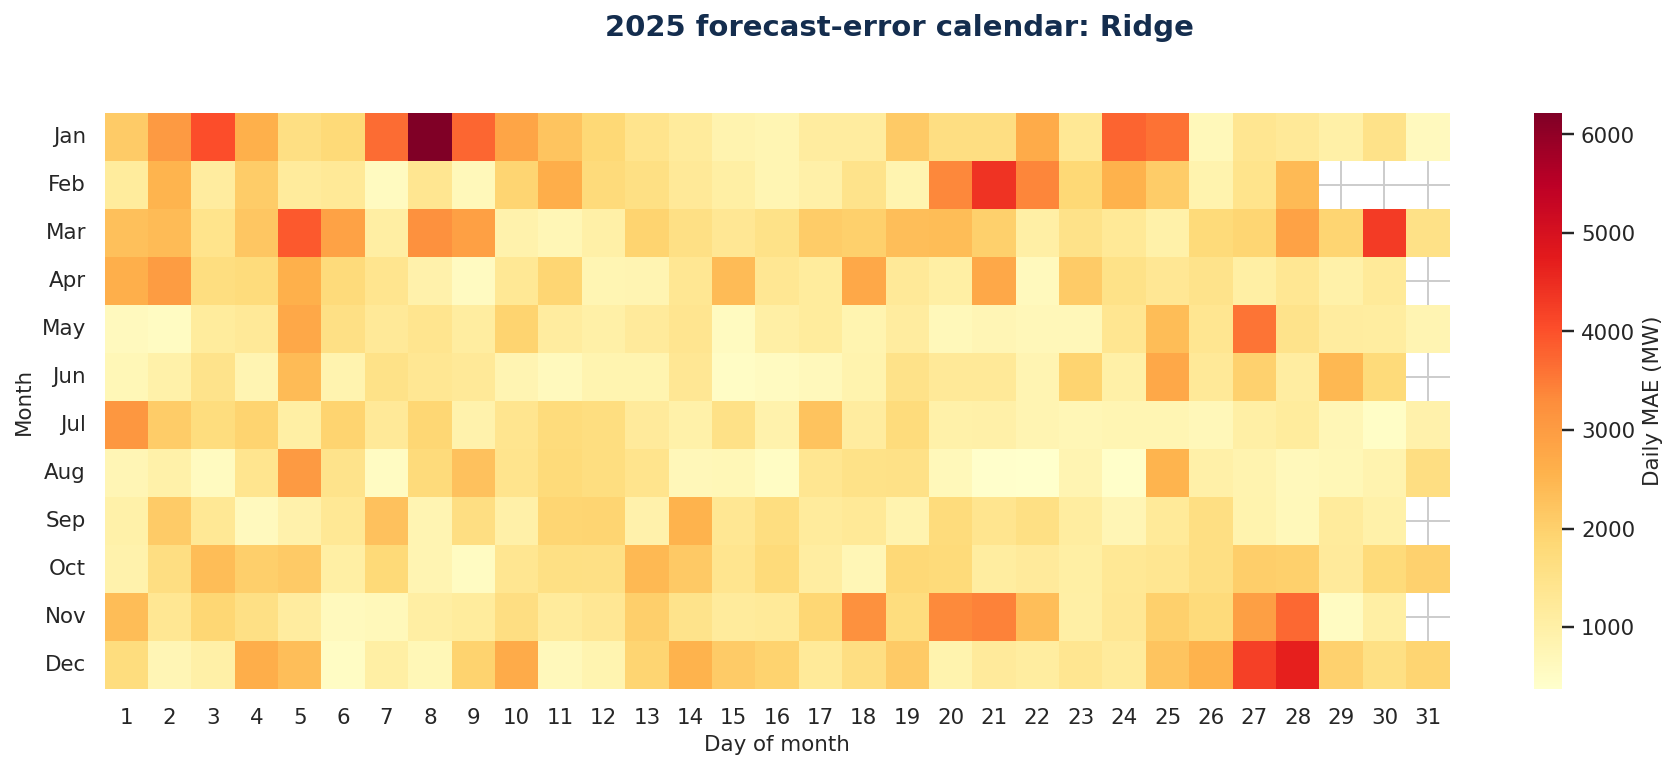

,SettlementDate,ClockTime,LocalTimeOccurrence,ActualDemandMW,SelectedForecastMW,SelectedErrorMW,SelectedAbsErrorMW,BankHolidayName,EMBEDDED_WIND_GENERATION,EMBEDDED_SOLAR_GENERATION,InvestigationContext
35440,2025-01-08,08:00,1,41247,"31,153.930","-10,093.070","10,093.070",None,1308,3,No calendar explanation: additional evidence n...
35441,2025-01-08,08:30,1,41910,"31,989.700","-9,920.300","9,920.300",None,1245,133,No calendar explanation: additional evidence n...
35439,2025-01-08,07:30,1,39701,"29,836.370","-9,864.630","9,864.630",None,1370,0,No calendar explanation: additional evidence n...
35442,2025-01-08,09:00,1,42895,"33,151.890","-9,743.110","9,743.110",None,1164,431,No calendar explanation: additional evidence n...
42122,2025-05-27,14:00,1,26953,"17,449.730","-9,503.270","9,503.270",None,2479,3060,No calendar explanation: additional evidence n...
42120,2025-05-27,13:00,1,27258,"17,777.640","-9,480.360","9,480.360",None,2490,3132,No calendar explanation: additional evidence n...
42121,2025-05-27,13:30,1,26963,"17,494.660","-9,468.340","9,468.340",None,2457,3234,No calendar explanation: additional evidence n...
42123,2025-05-27,14:30,1,27011,"17,555.930","-9,455.070","9,455.070",None,2500,3031,No calendar explanation: additional evidence n...
42119,2025-05-27,12:30,1,27349,"17,987.980","-9,361.020","9,361.020",None,2523,2784,No calendar explanation: additional evidence n...
35443,2025-01-08,09:30,1,42870,"33,624.170","-9,245.830","9,245.830",None,1083,780,No calendar explanation: additional evidence n...


,MAE_MW,RMSE_MW,Bias_MW,LargeErrorIntervals
SettlementDate,,,,
2025-01-08,"6,221.970","6,531.770","-6,221.970",28.000
2025-12-28,"4,675.750","4,792.000","-4,675.750",7.000
2025-02-21,"4,403.080","4,542.220","4,403.080",5.000
2025-03-30,"4,293.740","5,154.120","4,018.850",15.000
2025-12-27,"4,231.920","4,375.840","-4,231.920",1.000
2025-01-03,"4,036.680","4,219.130","-4,036.680",2.000
2025-03-05,"3,904.480","4,662.170","3,904.480",13.000
2025-01-24,"3,767.470","3,835.830","3,767.470",0.000
2025-01-09,"3,739.270","3,881.980","-3,739.270",2.000


In [21]:
daily_errors=test.groupby('SettlementDate').agg(
    MAE_MW=('SelectedAbsErrorMW','mean'),Bias_MW=('SelectedErrorMW','mean'),
    SquaredErrorMW2=('SelectedSquaredErrorMW2','mean'),
    LargeErrorIntervals=('LargeErrorFlag','sum'))
daily_errors['RMSE_MW']=np.sqrt(daily_errors.SquaredErrorMW2)
calendar=daily_errors.assign(Month=daily_errors.index.month,Day=daily_errors.index.day)
heat=calendar.pivot(index='Month',columns='Day',values='MAE_MW').reindex(index=range(1,13),columns=range(1,32))
fig,ax=plt.subplots(figsize=(13,5.6))
sns.heatmap(heat,cmap='YlOrRd',mask=heat.isna(),ax=ax,cbar_kws={'label':'Daily MAE (MW)'})
ax.set_yticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],rotation=0)
ax.set(xlabel='Day of month',ylabel='Month')
show_chart(fig,f'2025 forecast-error calendar: {selected_method}')

worst=test.nlargest(15,'SelectedAbsErrorMW').copy()
worst['InvestigationContext']=np.select(
    [worst.IsBankHolidayEW.eq(1),worst.IsChristmasPeriod.eq(1),worst.ExpectedPeriodsDay.ne(48),worst.IsWeekend.eq(1)],
    ['Bank holiday: calendar association','Christmas period: calendar association',
     'Clock-change day: alignment review','Weekend: profile review'],
    default='No calendar explanation: additional evidence needed')
show_table(worst[['SettlementDate','ClockTime','LocalTimeOccurrence','ActualDemandMW',
                  'SelectedForecastMW','SelectedErrorMW','SelectedAbsErrorMW',
                  'BankHolidayName','EMBEDDED_WIND_GENERATION','EMBEDDED_SOLAR_GENERATION',
                  'InvestigationContext']])
show_table(daily_errors.nlargest(10,'MAE_MW')[['MAE_MW','RMSE_MW','Bias_MW','LargeErrorIntervals']])


The highest daily MAE occurs on 8 January 2025. The largest interval
deviation is at 08:00 that day, when ridge underforecasts by
10,093 MW. The CSVs alone cannot confirm whether
weather, an operational event or another factor explains the deviation.


I plot the ten largest selected-method errors and average signed bias by
local time. This separates isolated large deviations from recurring
intraday forecast behaviour.


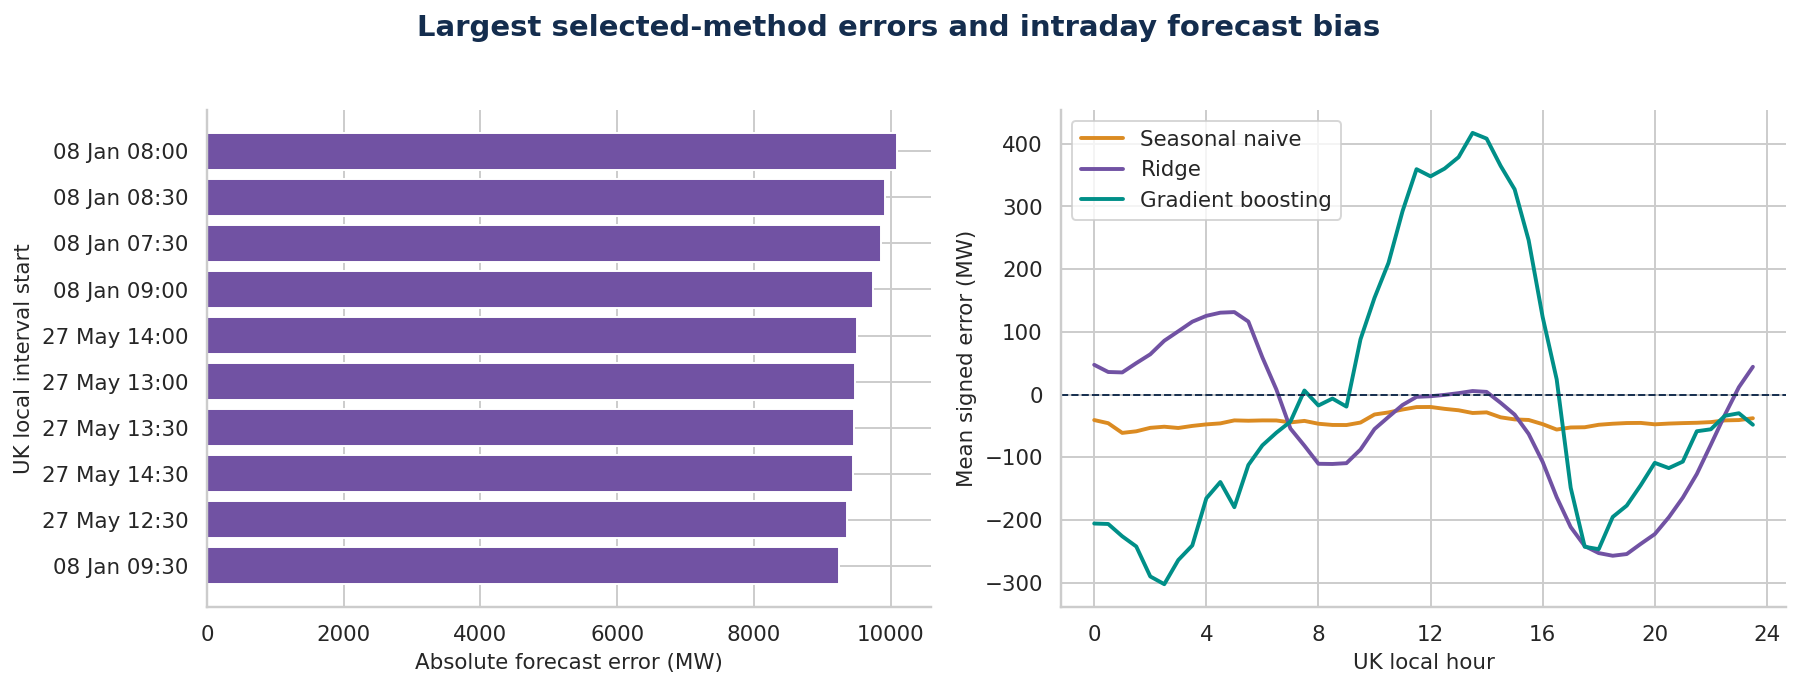

In [22]:
fig,axes=plt.subplots(1,2,figsize=(13,5))
top=worst.head(10).sort_values('SelectedAbsErrorMW')
labels=top.LocalStart.dt.strftime('%d %b %H:%M')
axes[0].barh(labels,top.SelectedAbsErrorMW,color=COLORS[selected_method])
axes[0].set(xlabel='Absolute forecast error (MW)',ylabel='UK local interval start')
for name,prefix in [('Seasonal naive','Baseline'),('Ridge','Ridge'),('Gradient boosting','Boosting')]:
    bias=test.groupby('ClockSlot')[f'{prefix}ErrorMW'].mean()
    axes[1].plot(bias.index/2,bias,label=name,color=COLORS[name],lw=2)
axes[1].axhline(0,color='#142d4e',ls='--',lw=1)
axes[1].set(xlabel='UK local hour',ylabel='Mean signed error (MW)',xticks=range(0,25,4))
axes[1].legend()
show_chart(fig,'Largest selected-method errors and intraday forecast bias')


The largest deviations cluster within a few days. Average intraday bias
also varies by model, so an overall bias close to zero does not mean the
forecast is equally balanced at every time of day.


I compare accuracy across weekends, seasons, holidays and clock-change
days. I also plot observed embedded generation against forecast errors
to look for associations that could guide further analysis.


,Grouping,Group,N,MAE_MW,RMSE_MW,Bias_MW,WAPE_Pct
0,DayType,Weekday,12528,"1,571.290","2,062.910",-78.190,5.830
1,DayType,Weekend,4992,"1,550.140","2,082.230",39.190,6.430
2,Season,Autumn,4370,"1,535.070","1,969.960",-90.940,5.760
3,Season,Spring,4414,"1,600.590","2,182.290",309.270,6.600
4,Season,Summer,4416,"1,246.290","1,631.880",-118.960,5.640
5,Season,Winter,4320,"1,885.760","2,416.080",-283.880,5.940
6,IsBankHolidayEW,0,17136,"1,546.800","2,047.320",-24.710,5.900
7,IsBankHolidayEW,1,384,"2,389.100","2,855.960",-939.070,10.410
8,ClockChangeDay,Autumn: 50 periods,50,"1,624.110","2,235.490",-901.750,6.460
9,ClockChangeDay,Normal: 48 periods,17424,"1,557.890","2,053.660",-53.020,5.950


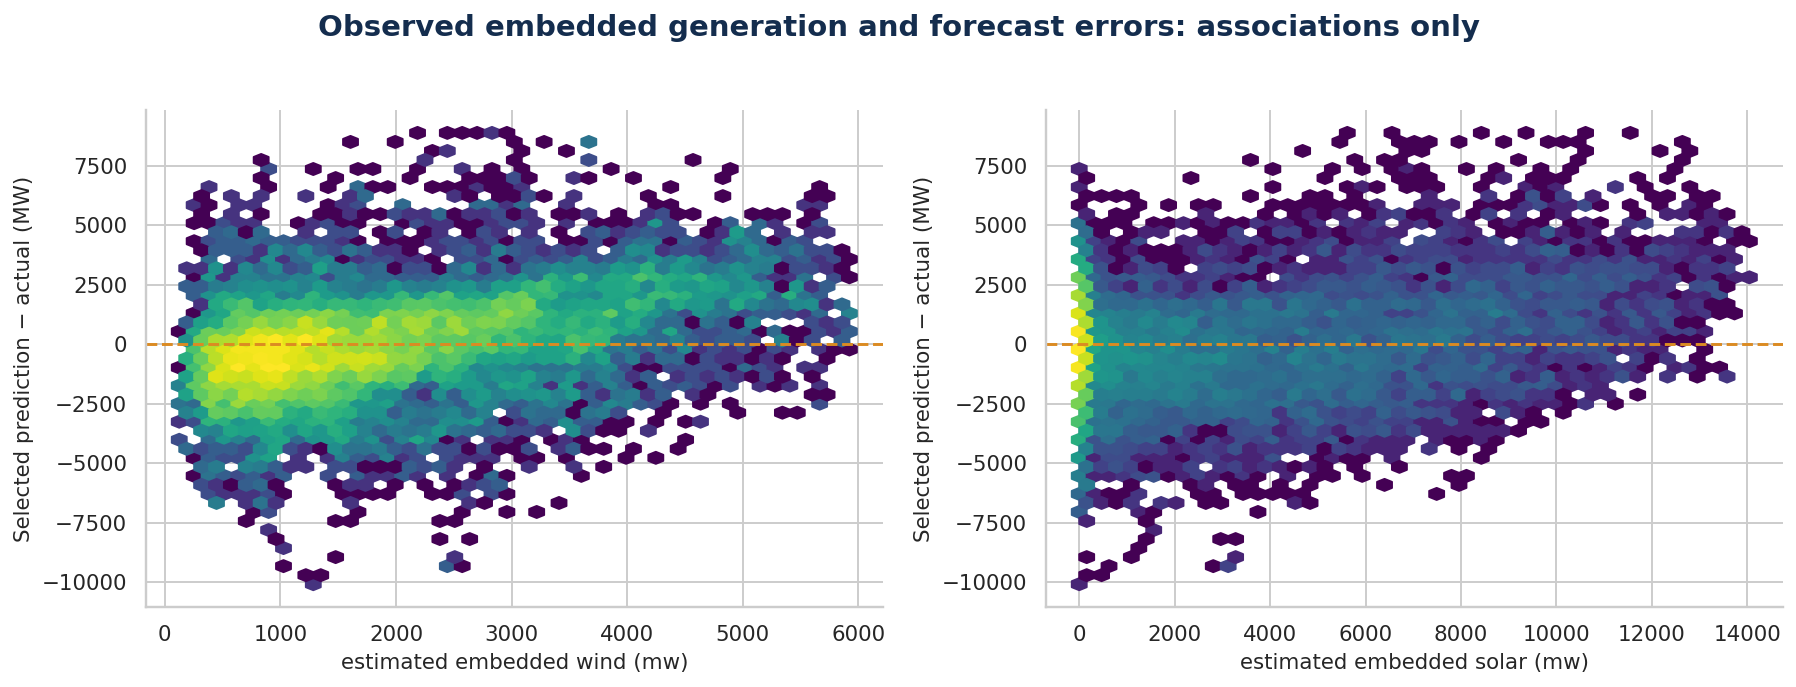

Holiday groups and clock-change groups contain few distinct days; treat them cautiously.


In [23]:
regime_rows=[]
for column in ['DayType','Season','IsBankHolidayEW','ClockChangeDay']:
    for value,part in test.groupby(column):
        regime_rows.append({'Grouping':column,'Group':str(value),
                            **score_predictions(part.ActualDemandMW,part.SelectedForecastMW)})
regimes=pd.DataFrame(regime_rows)
show_table(regimes)
fig,axes=plt.subplots(1,2,figsize=(13,5))
for ax,column in zip(axes,['EMBEDDED_WIND_GENERATION','EMBEDDED_SOLAR_GENERATION']):
    cloud=ax.hexbin(test[column],test.SelectedErrorMW,gridsize=45,mincnt=1,cmap='viridis',bins='log')
    ax.axhline(0,color='#db8b22',ls='--')
    ax.set(xlabel=column.replace('EMBEDDED_','Estimated embedded ').replace('_GENERATION',' (MW)').lower(),
           ylabel='Selected prediction − actual (MW)')
show_chart(fig,'Observed embedded generation and forecast errors: associations only')
print('Holiday groups and clock-change groups contain few distinct days; treat them cautiously.')


Accuracy differs between calendar groups. Holiday and clock-change results
cover few distinct days, so I treat them cautiously. The generation plots
show associations, but separating them from seasonal and intraday effects
would require further modelling.


I examine the highest-error day in more detail, showing actual demand,
the selected forecast, the baseline and signed interval errors.


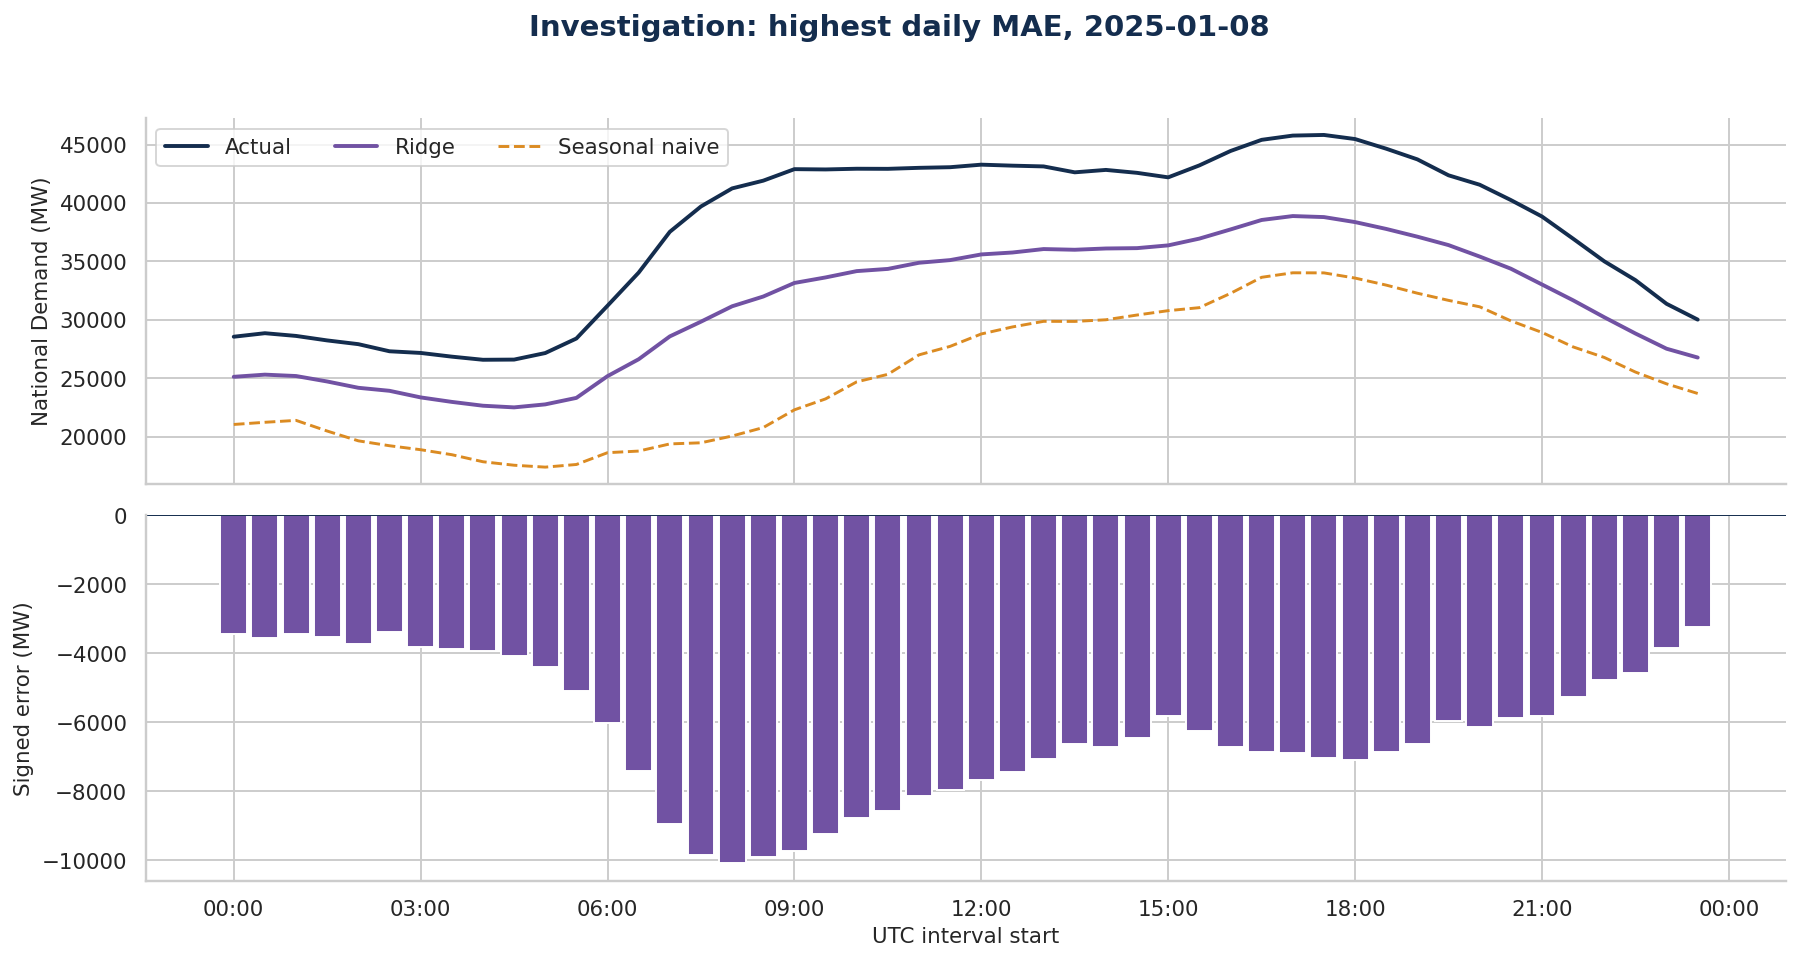

Calendar context: None Weekday Winter
This chart selects the largest error after evaluation and is not a representative accuracy example.


In [24]:
worst_date=daily_errors.MAE_MW.idxmax()
day=test.loc[test.SettlementDate.eq(worst_date)]
fig,axes=plt.subplots(2,1,figsize=(13,7),sharex=True)
axes[0].plot(day.UTCStart,day.ActualDemandMW,color=COLORS['Actual'],lw=2,label='Actual')
axes[0].plot(day.UTCStart,day.SelectedForecastMW,color=COLORS[selected_method],lw=2,label=selected_method)
axes[0].plot(day.UTCStart,day.BaselineForecastMW,color=COLORS['Seasonal naive'],ls='--',label='Seasonal naive')
axes[0].set(ylabel='National Demand (MW)')
axes[0].legend(ncol=3)
axes[1].bar(day.UTCStart,day.SelectedErrorMW,width=.018,color=COLORS[selected_method])
axes[1].axhline(0,color=COLORS['Actual'],lw=1)
axes[1].set(xlabel='UTC interval start',ylabel='Signed error (MW)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
show_chart(fig,f'Investigation: highest daily MAE, {worst_date.date()}')
print('Calendar context:',day.BankHolidayName.iloc[0],day.DayType.iloc[0],day.Season.iloc[0])
print('This chart selects the largest error after evaluation and is not a representative accuracy example.')


On 8 January, both the baseline and ridge forecast remain below actual
demand for most of the day. This is an investigation of the largest
daily error, rather than a representative example of overall performance.


## 8. Export the Tableau dataset
I keep one row per half-hour interval, with separate columns for each
model's forecast and errors. This avoids duplicating actual demand or
energy when comparing methods in Tableau.

Training and embargo rows retain their actuals but have blank forecast
measures. I include local and UTC timestamps, calendar fields, source
identifiers and quality flags. I check the exported file by reading it back.


In [25]:
export=df.copy()
export['SettlementDate']=export.SettlementDate.dt.strftime('%Y-%m-%d')
export['PeriodStartUTC']=df.UTCStart.dt.strftime('%Y-%m-%d %H:%M:%S')
export['PeriodStartLocal']=df.LocalStart.dt.strftime('%Y-%m-%d %H:%M:%S')
export['LocalStartISO']=df.LocalStart.map(lambda value:value.isoformat())
export['ForecastIssueUTC']=df.ForecastIssueUTC.dt.strftime('%Y-%m-%d %H:%M:%S')
export['LatestFeatureEndUTC']=df.LatestFeatureEndUTC.dt.strftime('%Y-%m-%d %H:%M:%S')
export['ModelTrainingEndDate']=df.ModelTrainingEndDate.dt.strftime('%Y-%m-%d')
export['WeekStart']=df.WeekStart.dt.strftime('%Y-%m-%d')
export['EvaluationPurpose']=df.EvaluationSplit.map({
    'Train':'Historical training actuals',
    'Embargo':'Year-end embargo: actuals retained, no forecasts scored',
    'Validation':'Validation used for model selection',
    'Test':'Held-out test of frozen models'})

export_cols=[
    'IntervalID','SettlementDate','SETTLEMENT_PERIOD','PeriodStartUTC','PeriodStartLocal',
    'LocalStartISO','LocalTimeOccurrence','UTCOffsetMinutes','ClockTime','ClockSlot','HourOfDay',
    'Year','MonthNumber','MonthName','YearMonth','Season','DayOfWeekNumber','DayOfWeekName',
    'DayType','IsWeekend','IsBST','IsBankHolidayEW','BankHolidayName','IsChristmasPeriod','WeekStart',
    'IntervalHours','ActualDemandMW','DemandEnergyMWh',
    *source_numeric_cols[1:],
    'EvaluationSplit','EvaluationPurpose','ModelEligibleFlag','ForecastEvaluationFlag',
    'ForecastIssueUTC','LatestFeatureEndUTC','ModelTrainingEndDate','SelectedModel',
    'BaselineAlignmentRule','Lag7DaysMW',
    *[column for prefix,forecast in error_prefixes.items()
      for column in [forecast,f'{prefix}ErrorMW',f'{prefix}AbsErrorMW',f'{prefix}SquaredErrorMW2']],
    'SelectedErrorPct','ErrorDirection','LargeErrorThresholdMW','LargeErrorFlag','SelectedDeviationRank',
    'SourceRecordPresent','MissingPeriodFlag','MissingActualFlag','InvalidDemandFlag',
    'SourceMissingFieldsCount','DayAuditAnchor','ExpectedPeriodsDay','ObservedPeriodsDay',
    'MissingPeriodsDay','DuplicateRowsRemovedDay','ClockChangeDay',
    'SourceFile','SourceSHA256','SourceSnapshotDate',
]

export_cols=list(dict.fromkeys(export_cols))
export=export[export_cols]
assert export.IntervalID.is_unique
assert not export.duplicated(['SettlementDate','SETTLEMENT_PERIOD']).any()
assert len(export)==len(grid)
assert export.loc[df.EvaluationSplit.eq('Train'),list(prediction_columns.values())].isna().all().all()
assert export.loc[test_mask,list(prediction_columns.values())].notna().all().all()
assert np.allclose(export.DemandEnergyMWh,export.ActualDemandMW*0.5,equal_nan=True)
assert (export.select_dtypes(include='number').replace([np.inf,-np.inf],np.nan).isna().sum()
        .equals(export.select_dtypes(include='number').isna().sum()))
for prefix,column in error_prefixes.items():
    assert np.allclose(export[f'{prefix}ErrorMW'],export[column]-export.ActualDemandMW,equal_nan=True)
    assert np.allclose(export[f'{prefix}SquaredErrorMW2'],export[f'{prefix}ErrorMW']**2,equal_nan=True)
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
csv_path=OUTPUT_DIR/'GB_Electricity_Demand_Tableau.csv'
export.to_csv(csv_path,index=False,encoding='utf-8',float_format='%.6f',na_rep='')
roundtrip=pd.read_csv(csv_path,low_memory=False)
assert roundtrip.shape==export.shape
assert roundtrip.IntervalID.is_unique
assert int(roundtrip.MissingPeriodFlag.sum())==int(df.MissingPeriodFlag.sum())
assert np.allclose(roundtrip.ActualDemandMW,df.ActualDemandMW,equal_nan=True)
print(f'CSV exported: {csv_path.name}')
print(f'Rows: {len(export):,}; columns: {export.shape[1]}; size: {csv_path.stat().st_size/1_000_000:.1f} MB.')
print('One interval per row. Export round-trip, uniqueness, forecast and energy checks passed.')
show_table(export[['SettlementDate','ClockTime','EvaluationSplit','ActualDemandMW',
                   'BaselineForecastMW','RidgeForecastMW','BoostingForecastMW','SelectedForecastMW',
                   'SelectedErrorMW']].iloc[-8:])


CSV exported: GB_Electricity_Demand_Tableau.csv
Rows: 52,608; columns: 93; size: 40.5 MB.
One interval per row. Export round-trip, uniqueness, forecast and energy checks passed.


,SettlementDate,ClockTime,EvaluationSplit,ActualDemandMW,BaselineForecastMW,RidgeForecastMW,BoostingForecastMW,SelectedForecastMW,SelectedErrorMW
52600,2025-12-31,20:00,Test,32389,"32,250.000","32,225.710","31,230.250","32,225.710",-163.290
52601,2025-12-31,20:30,Test,31120,"30,150.000","30,669.860","29,910.300","30,669.860",-450.140
52602,2025-12-31,21:00,Test,29723,"28,840.000","29,208.020","28,302.050","29,208.020",-514.980
52603,2025-12-31,21:30,Test,28633,"28,187.000","27,995.680","27,953.190","27,995.680",-637.320
52604,2025-12-31,22:00,Test,27381,"26,741.000","26,401.830","26,536.240","26,401.830",-979.170
52605,2025-12-31,22:30,Test,26563,"25,453.000","24,977.660","24,304.850","24,977.660","-1,585.340"
52606,2025-12-31,23:00,Test,25481,"24,399.000","23,689.640","23,590.700","23,689.640","-1,791.360"
52607,2025-12-31,23:30,Test,24730,"23,641.000","22,731.710","22,600.090","22,731.710","-1,998.290"


The export contains 52,608 rows and 93 fields. Interval keys are unique,
the forecast errors reconcile with prediction minus actual, and energy
equals demand multiplied by the half-hour interval duration.


I group the exported fields into time and calendar, actuals and context,
forecasts and evaluation, and data quality. This helps me check the field
types when setting up the Tableau connection.


In [26]:
schema_groups = {
    'Time and calendar': export_cols[:26],
    'Actuals and observed system context': ['ActualDemandMW','DemandEnergyMWh',*source_numeric_cols[1:]],
    'Forecasts and evaluation': ['EvaluationSplit','EvaluationPurpose','ModelEligibleFlag',
        'ForecastEvaluationFlag','ForecastIssueUTC','LatestFeatureEndUTC','ModelTrainingEndDate',
        'SelectedModel','BaselineAlignmentRule','Lag7DaysMW',
        *[c for p,f in error_prefixes.items() for c in [f,f'{p}ErrorMW',f'{p}AbsErrorMW',f'{p}SquaredErrorMW2']],
        'SelectedErrorPct','ErrorDirection','LargeErrorThresholdMW','LargeErrorFlag','SelectedDeviationRank'],
    'Data quality and provenance': ['SourceRecordPresent','MissingPeriodFlag','MissingActualFlag',
        'InvalidDemandFlag','SourceMissingFieldsCount','DayAuditAnchor','ExpectedPeriodsDay',
        'ObservedPeriodsDay','MissingPeriodsDay','DuplicateRowsRemovedDay','ClockChangeDay',
        'SourceFile','SourceSHA256','SourceSnapshotDate'],
}
schema_inventory = pd.DataFrame([
    {'Group':group,'Fields':', '.join(fields),'FieldCount':len(fields)}
    for group,fields in schema_groups.items()
])
with pd.option_context('display.max_colwidth',None):
    show_table(schema_inventory)
print('MW = power; MWh = interval energy; MW2 = squared error.')
print('Flags use 1/0; unavailable forecast measures use blanks. Dates use ISO ordering.')
print('ModelTrainingEndDate applies to fitted models. The seasonal baseline has no fitted training stage.')


,Group,Fields,FieldCount
0,Time and calendar,"IntervalID, SettlementDate, SETTLEMENT_PERIOD, PeriodStartUTC, PeriodStartLocal, LocalStartISO, LocalTimeOccurrence, UTCOffsetMinutes, ClockTime, ClockSlot, HourOfDay, Year, MonthNumber, MonthName, YearMonth, Season, DayOfWeekNumber, DayOfWeekName, DayType, IsWeekend, IsBST, IsBankHolidayEW, BankHolidayName, IsChristmasPeriod, WeekStart, IntervalHours",26
1,Actuals and observed system context,"ActualDemandMW, DemandEnergyMWh, ND, TSD, ENGLAND_WALES_DEMAND, EMBEDDED_WIND_GENERATION, EMBEDDED_WIND_CAPACITY, EMBEDDED_SOLAR_GENERATION, EMBEDDED_SOLAR_CAPACITY, NON_BM_STOR, PUMP_STORAGE_PUMPING, SCOTTISH_TRANSFER, IFA_FLOW, IFA2_FLOW, BRITNED_FLOW, MOYLE_FLOW, EAST_WEST_FLOW, NEMO_FLOW, NSL_FLOW, ELECLINK_FLOW, VIKING_FLOW, GREENLINK_FLOW",22
2,Forecasts and evaluation,"EvaluationSplit, EvaluationPurpose, ModelEligibleFlag, ForecastEvaluationFlag, ForecastIssueUTC, LatestFeatureEndUTC, ModelTrainingEndDate, SelectedModel, BaselineAlignmentRule, Lag7DaysMW, BaselineForecastMW, BaselineErrorMW, BaselineAbsErrorMW, BaselineSquaredErrorMW2, RidgeForecastMW, RidgeErrorMW, RidgeAbsErrorMW, RidgeSquaredErrorMW2, BoostingForecastMW, BoostingErrorMW, BoostingAbsErrorMW, BoostingSquaredErrorMW2, SelectedForecastMW, SelectedErrorMW, SelectedAbsErrorMW, SelectedSquaredErrorMW2, SelectedErrorPct, ErrorDirection, LargeErrorThresholdMW, LargeErrorFlag, SelectedDeviationRank",31
3,Data quality and provenance,"SourceRecordPresent, MissingPeriodFlag, MissingActualFlag, InvalidDemandFlag, SourceMissingFieldsCount, DayAuditAnchor, ExpectedPeriodsDay, ObservedPeriodsDay, MissingPeriodsDay, DuplicateRowsRemovedDay, ClockChangeDay, SourceFile, SourceSHA256, SourceSnapshotDate",14


MW = power; MWh = interval energy; MW2 = squared error.
Flags use 1/0; unavailable forecast measures use blanks. Dates use ISO ordering.
ModelTrainingEndDate applies to fitted models. The seasonal baseline has no fitted training stage.


The file contains the fields needed for the three dashboard sections.
Quality flags can be summed, while repeated daily audit counts use
`DayAuditAnchor = 1`. The large-error threshold uses `MIN` or `ATTR`.


## 9. Main findings
I bring together the data-quality checks, demand patterns and held-out
model results before moving to the Tableau dashboards.


In [27]:
winner_test=metrics.loc[metrics.Split.eq('Test') & metrics.Model.eq(selected_method)].iloc[0]
baseline_test=metrics.loc[metrics.Split.eq('Test') & metrics.Model.eq('Seasonal naive')].iloc[0]
peak_slot=df.groupby('ClockSlot').ActualDemandMW.mean().idxmax()
weekday_mean=df.loc[df.IsWeekend.eq(0),'ActualDemandMW'].mean()
weekend_mean=df.loc[df.IsWeekend.eq(1),'ActualDemandMW'].mean()
seasons=df.groupby('Season').ActualDemandMW.mean()
largest=df.loc[test_mask].nlargest(1,'SelectedAbsErrorMW').iloc[0]
findings=pd.DataFrame([
    {'Topic':'Coverage','Finding':f'{len(df):,} expected intervals across 1,096 local days; '
     f'{df.SourceRecordPresent.mean()*100:.1f}% observed coverage; '
     f'{int(df.MissingActualFlag.sum())} missing actuals; {int(removed_mask.sum())} duplicate rows removed.'},
    {'Topic':'Clock changes','Finding':'All six clock-change days retain their true 46 or 50 settlement periods.'},
    {'Topic':'Intraday','Finding':f'The highest average demand slot is {int(peak_slot//2):02d}:{int(peak_slot%2*30):02d} UK local time.'},
    {'Topic':'Working week','Finding':f'Weekday mean demand is {weekday_mean:,.0f} MW; weekend mean is '
     f'{weekend_mean:,.0f} MW ({(1-weekend_mean/weekday_mean)*100:.1f}% lower).'},
    {'Topic':'Seasonality','Finding':f'Highest seasonal mean: {seasons.idxmax()} ({seasons.max():,.0f} MW). '
     f'Lowest: {seasons.idxmin()} ({seasons.min():,.0f} MW).'},
    {'Topic':'Model selection','Finding':f'{selected_method} was selected using 2024 MAE only.'},
    {'Topic':'Held-out accuracy','Finding':f'2025 selected-method MAE {winner_test.MAE_MW:,.0f} MW; '
     f'RMSE {winner_test.RMSE_MW:,.0f} MW; mean signed error {winner_test.Bias_MW:+,.0f} MW.'},
    {'Topic':'Baseline comparison','Finding':f'2025 baseline MAE {baseline_test.MAE_MW:,.0f} MW; '
     f'selected-method MAE improvement {winner_test.MAEImprovementVsBaselinePct:.1f}%.'},
    {'Topic':'Largest deviation','Finding':f'{largest.LocalStart}: signed error {largest.SelectedErrorMW:+,.0f} MW. '
     'Calendar and context associations are investigation leads, not verified causes.'},
])
with pd.option_context('display.max_colwidth',180):
    show_table(findings)
print('Finished: executed notebook and one Tableau CSV.')


,Topic,Finding
0,Coverage,"52,608 expected intervals across 1,096 local days; 100.0% observed coverage; 0 missing actuals; 0 duplicate rows removed."
1,Clock changes,All six clock-change days retain their true 46 or 50 settlement periods.
2,Intraday,The highest average demand slot is 18:30 UK local time.
3,Working week,"Weekday mean demand is 27,035 MW; weekend mean is 23,990 MW (11.3% lower)."
4,Seasonality,"Highest seasonal mean: Winter (30,691 MW). Lowest: Summer (22,164 MW)."
5,Model selection,Ridge was selected using 2024 MAE only.
6,Held-out accuracy,"2025 selected-method MAE 1,565 MW; RMSE 2,068 MW; mean signed error -45 MW."
7,Baseline comparison,"2025 baseline MAE 2,178 MW; selected-method MAE improvement 28.1%."
8,Largest deviation,"2025-01-08 08:00:00+00:00: signed error -10,093 MW. Calendar and context associations are investigation leads, not verified causes."


Finished: executed notebook and one Tableau CSV.


Ridge improves test MAE by 28.1% over the previous-week
baseline. Demand follows clear daily, weekly and seasonal patterns, while
the largest remaining errors show where additional weather and event
information could help. I would test any new features on a later held-out
period before claiming a further improvement.


## 10. Tableau calculations

I connect the exported CSV as a **Text File**. Set `SettlementDate` and
`WeekStart` to Date, timestamp fields to Date & Time, and `ClockTime` to String.
Set numeric measures to Number (decimal) and flags/period numbers to Number
(whole). The source SHA and interval ID remain strings. For forecast dashboards,
filter `EvaluationSplit = Test` and `ForecastEvaluationFlag = 1` by default.
The Overview dashboard can use all years. A validation view must be labelled
as validation used for model selection.

I use a String parameter called **Forecast Method** with values `Selected`,
`Seasonal naive`, `Ridge`, and `Gradient boosting`.

**Chosen Forecast MW**
```tableau
CASE [Forecast Method]
WHEN "Selected" THEN [SelectedForecastMW]
WHEN "Seasonal naive" THEN [BaselineForecastMW]
WHEN "Ridge" THEN [RidgeForecastMW]
WHEN "Gradient boosting" THEN [BoostingForecastMW]
END
```

**Chosen Error MW**: `[Chosen Forecast MW] - [ActualDemandMW]`  
**Chosen Absolute Error MW**: `ABS([Chosen Error MW])`  
**Chosen Squared Error MW2**: `[Chosen Error MW] * [Chosen Error MW]`  
**MAE MW**: `AVG([Chosen Absolute Error MW])`  
**RMSE MW**: `SQRT(AVG([Chosen Squared Error MW2]))`  
**Bias MW**: `AVG([Chosen Error MW])`

**WAPE %** (evaluate only forecast-eligible rows)
```tableau
100 * SUM([Chosen Absolute Error MW]) / SUM(ABS([ActualDemandMW]))
```

**Observed Coverage %**
```tableau
100 * SUM([SourceRecordPresent]) / COUNT([IntervalID])
```
**Missing source periods**: `SUM([MissingPeriodFlag])`  
**Missing actual demand**: `SUM([MissingActualFlag])`  
**Source missing numeric cells**: `SUM([SourceMissingFieldsCount])`  
**Duplicate rows removed**
```tableau
SUM(IF [DayAuditAnchor] = 1 THEN [DuplicateRowsRemovedDay] ELSE 0 END)
```
**National-demand energy MWh**: `SUM([DemandEnergyMWh])`  
**Mean demand MW**: `AVG([ActualDemandMW])`  
**Peak demand MW**: `MAX([ActualDemandMW])`

Do not sum MW as energy. Do not average previously aggregated RMSE values.
Recompute RMSE from interval squared errors after applying the desired filters.
The precomputed ranks and large-error flags refer to the selected method;
changing the parameter requires a Tableau rank or threshold calculation for the
chosen method. The CSV's threshold is always the selected method's fixed
validation threshold, not a general threshold for all algorithms.


### Dashboard plan

| Dashboard | Sheet | Title | Fields and aggregation |
|---|---:|---|---|
| Demand Overview | 01 | National Demand Over Time | `PeriodStartUTC` or `SettlementDate`; `AVG(ActualDemandMW)`; show raw half-hours or daily means clearly |
| Demand Overview | 02 | Average Intraday Demand Profile | `ClockSlot` ascending / `ClockTime`; `AVG(ActualDemandMW)`; colour by `Year` |
| Demand Overview | 03 | Weekday vs Weekend Demand | `ClockSlot`; `AVG(ActualDemandMW)`; colour by `DayType` |
| Demand Overview | 04 | Monthly and Seasonal Demand Patterns | `MonthNumber` / `MonthName`, `Season`, `Year`; `AVG(ActualDemandMW)` |
| Forecast Performance | 05 | Actual vs Forecast Demand | `PeriodStartUTC`; actual and `Chosen Forecast MW`; test and eligible filters |
| Forecast Performance | 06 | Baseline vs Model Accuracy | Measure Names/Values using `AVG(BaselineAbsErrorMW)`, `AVG(RidgeAbsErrorMW)`, `AVG(BoostingAbsErrorMW)`; corresponding RMSE calculations; no data pivot needed |
| Forecast Performance | 07 | Forecast Error Distribution | Create 250-MW bins on `Chosen Error MW`; `COUNT(IntervalID)`; mark zero |
| Forecast Performance | 08 | Forecast Accuracy Over Time | `YearMonth`; chosen MAE and RMSE; parameter controls model |
| Variance & Quality | 09 | Forecast Error Calendar | Date calendar or month/day grid; `AVG(Chosen Absolute Error MW)` per date; colour by daily MAE |
| Variance & Quality | 10 | Largest Forecast Deviations | `IntervalID`, UK local timestamp, actual and forecast; descending chosen absolute error, Top 15; selected method can use `SelectedDeviationRank` |
| Variance & Quality | 11 | Forecast Bias by Time of Day | `ClockSlot` / `ClockTime`; `AVG(Chosen Error MW)`; reference line at zero |
| Variance & Quality | 12 | Data Quality & Coverage | Additive missing/coverage flags, daily anchors, source file and expected day lengths; use all years and explain local-clock days |

I use a date-range control and the Forecast Method parameter across the
dashboards, with navigation buttons and linked chart selections. Tooltips should show MW/MWh units, local-time offset,
forecast issue time, evaluation split and error sign. Keep the quality sheet's
data-source coverage visible across all years rather than accidentally applying
the test-only forecast filter to it.


## 11. Limitations and next steps

The backtest uses the final historic outturn files. Original publication times
and unrevised data vintages are unavailable, so I cannot confirm operational
availability at the assumed issue time. The predictions are from the models
in this notebook; I have not compared published NESO forecasts.

I have one held-out year and no temperature forecasts, outage records or
verified event explanations. The holiday feature also excludes additional
Scottish holidays. These gaps limit how confidently I can explain individual
deviations or generalise the results to future years.

Next, I would add weather forecasts and a fuller calendar, examine the
largest deviations against external event records, and repeat the evaluation
on later data. Prediction intervals would also help assess uncertainty.

### Data references

- [NESO historic demand 2023](https://www.neso.energy/data-portal/historic-demand-data/historic_demand_data_2023)
- [NESO historic demand 2024](https://www.neso.energy/data-portal/historic-demand-data/historic_demand_data_2024)
- [NESO historic demand 2025](https://www.neso.energy/data-portal/historic-demand-data/historic_demand_data_2025)
- [Elexon settlement clock-change guidance](https://assets.elexon.co.uk/wp-content/uploads/sites/11/2012/02/04142749/el01921.pdf)
- [GOV.UK bank holidays](https://www.gov.uk/bank-holidays?force_isolation=true)

The source definitions and holiday dates were checked on 5 October 2026.
Source flow signs are retained without relabelling them as imports or exports.
